# Proyecto de regresion: prediccion de ventas globales de videojuegos de PS4

## 3.1 Comprension del negocio

### Introduccion al problema

El dataset contiene videojuegos de PlayStation 4 con informacion de anio, genero, publicador y ventas en distintas regiones. Cada registro representa un juego y permite analizar su desempenio comercial.

El fenomeno representado es la distribucion de ventas de juegos de PS4 a nivel internacional. Analizarlo es util para identificar patrones de exito segun region, genero, anio o empresa publicadora.

El problema consiste en estimar las ventas globales finales de un videojuego a partir de sus ventas regionales observadas y caracteristicas generales. Es un problema de regresion porque la salida es un valor numerico continuo.

### Objetivo de la prediccion

La variable a predecir es `Global_Sales`, tomada de la columna original `Global`. Representa las ventas globales del videojuego en millones de copias vendidas.

Predecir esta variable es importante porque las ventas globales resumen el resultado comercial total. La prediccion puede apoyar la validacion de reportes, comparacion de desempenio por regiones y consolidacion de ventas.

### Aplicacion del modelo

El modelo podria ser usado por analistas, publicadores o equipos comerciales para estimar ventas globales cuando ya se cuenta con ventas regionales parciales u observadas. Sus resultados ayudarian a revisar reportes, detectar posibles inconsistencias y comparar desempenio internacional.

Una prediccion incorrecta podria generar interpretaciones equivocadas del desempenio global. El modelo no debe interpretarse como una prediccion antes del lanzamiento, porque utiliza ventas regionales como entradas.


## 3.2 Comprensión de los datos

En esta etapa se revisa la estructura original del dataset, sus atributos, problemas de calidad y primeras relaciones con `Global_Sales`.

### Descripción general

- **Nombre del dataset:** Video Games Sales Dataset, archivo `PS4_GamesSales.csv`.
- **Fuente:** Kaggle, dataset publicado como `sidtwr/videogames-sales-dataset`.
- **URL:** https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset
- **Unidad de análisis:** cada fila representa un videojuego de PlayStation 4.
- **Variable dependiente:** `Global_Sales`, obtenida a partir de la columna original `Global`.
- **Unidad de la variable dependiente:** millones de copias vendidas a nivel global.

El archivo contiene videojuegos de PS4 con año, género, publicador y ventas regionales/globales en millones de copias.


In [39]:
# Importación de librerías principales
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='Set2')


### Carga del dataset

El dataset se carga remotamente desde GitHub Raw. Se usa `latin1` por la codificacion del archivo y se leen `N/A` y cadenas vacias como nulos.


In [ ]:
# URL del archivo CSV en GitHub en formato RAW
url = 'https://raw.githubusercontent.com/JoadanMatias10/videogames/main/PS4_GamesSales.csv'

# Datos descriptivos usados en la tabla de comprensión de datos
DATASET_NAME = 'Video Games Sales Dataset - PS4_GamesSales.csv'
DATASET_SOURCE = 'Kaggle: sidtwr/videogames-sales-dataset; GitHub Raw'
DATASET_URL = url

# Cargar el dataset
dataset_raw = pd.read_csv(url, encoding='latin1', na_values=['N/A', ''], keep_default_na=True)
# La columna original se llama Global; se renombra a Global_Sales para identificarla como variable objetivo.
dataset = dataset_raw.rename(columns={'Global': 'Global_Sales'}).copy()

# Mostrar las primeras filas
dataset.head()


In [41]:
# Dimensiones originales solicitadas
dataset.shape


(1034, 9)

In [42]:
target_original = 'Global'
target = 'Global_Sales'

general_description = pd.DataFrame({
    'Elemento': [
        'Nombre del dataset', 'Fuente', 'URL', 'Número original de registros',
        'Número original de columnas', 'Número de variables independientes',
        'Variable dependiente', 'Contenido general'
    ],
    'Valor': [
        DATASET_NAME,
        DATASET_SOURCE,
        DATASET_URL,
        dataset_raw.shape[0],
        dataset_raw.shape[1],
        dataset_raw.shape[1] - 1,
        f'{target} (columna original: {target_original})',
        'Videojuegos de PS4 con año, género, publicador y ventas regionales/globales en millones de copias.'
    ]
})

general_description


,Elemento,Valor
0,Nombre del dataset,Video Games Sales Dataset - PS4_GamesSales.csv
1,Fuente,Kaggle: sidtwr/videogames-sales-dataset
2,URL,https://www.kaggle.com/datasets/sidtwr/videoga...
3,Número original de registros,1034
4,Número original de columnas,9
5,Número de variables independientes,8
6,Variable dependiente,Global_Sales (columna original: Global)
7,Contenido general,"Videojuegos de PS4 con año, género, publicador..."


**Interpretación:** el dataset es tabular y la variable objetivo es `Global_Sales`. Las ventas regionales se revisarán con cuidado porque están muy relacionadas con el total global.


### Descripción de atributos

La tabla resume los atributos originales, su tipo, dato en Python y nulos. La columna original `Global` se usará como `Global_Sales`.


In [43]:
attribute_metadata = {
    'Game': {
        'Descripción': 'Nombre del videojuego de PlayStation 4.',
        'Tipo de atributo': 'Nominal'
    },
    'Year': {
        'Descripción': 'Año de lanzamiento del videojuego.',
        'Tipo de atributo': 'Discreto'
    },
    'Genre': {
        'Descripción': 'Género principal del videojuego.',
        'Tipo de atributo': 'Nominal'
    },
    'Publisher': {
        'Descripción': 'Empresa publicadora o distribuidora del videojuego.',
        'Tipo de atributo': 'Nominal'
    },
    'North America': {
        'Descripción': 'Ventas en Norteamérica, expresadas en millones de copias.',
        'Tipo de atributo': 'Continuo'
    },
    'Europe': {
        'Descripción': 'Ventas en Europa, expresadas en millones de copias.',
        'Tipo de atributo': 'Continuo'
    },
    'Japan': {
        'Descripción': 'Ventas en Japón, expresadas en millones de copias.',
        'Tipo de atributo': 'Continuo'
    },
    'Rest of World': {
        'Descripción': 'Ventas en el resto del mundo, expresadas en millones de copias.',
        'Tipo de atributo': 'Continuo'
    },
    'Global': {
        'Descripción': 'Ventas globales totales del videojuego, expresadas en millones de copias.',
        'Tipo de atributo': 'Continuo'
    }
}

attribute_table = pd.DataFrame({
    'Atributo': dataset_raw.columns,
    'Descripción': [attribute_metadata[col]['Descripción'] for col in dataset_raw.columns],
    'Tipo de atributo': [attribute_metadata[col]['Tipo de atributo'] for col in dataset_raw.columns],
    'Tipo de dato en Python': dataset_raw.dtypes.astype(str).values,
    'Nulos': dataset_raw.isna().sum().values,
    'Porcentaje de nulos': (dataset_raw.isna().mean().values * 100).round(2)
})

attribute_table


,Atributo,Descripción,Tipo de atributo,Tipo de dato en Python,Nulos,Porcentaje de nulos
0,Game,Nombre del videojuego de PlayStation 4.,Nominal,str,0,0.0000
1,Year,Año de lanzamiento del videojuego.,Discreto,float64,209,20.2100
2,Genre,Género principal del videojuego.,Nominal,str,0,0.0000
3,Publisher,Empresa publicadora o distribuidora del videoj...,Nominal,str,209,20.2100
4,North America,"Ventas en Norteamérica, expresadas en millones...",Continuo,float64,0,0.0000
5,Europe,"Ventas en Europa, expresadas en millones de co...",Continuo,float64,0,0.0000
6,Japan,"Ventas en Japón, expresadas en millones de cop...",Continuo,float64,0,0.0000
7,Rest of World,"Ventas en el resto del mundo, expresadas en mi...",Continuo,float64,0,0.0000
8,Global,"Ventas globales totales del videojuego, expres...",Continuo,float64,0,0.0000


**Interpretación:** `Game`, `Genre` y `Publisher` son nominales; `Year` es discreta; las ventas son continuas. Los nulos en `Year` y `Publisher` deberán tratarse antes del modelado.


### Calidad de los datos

Se revisan duplicados, nulos, invalidos, inconsistencias, atipicos, baja variabilidad, identificadores y la relacion directa entre ventas regionales y `Global_Sales`.


In [44]:
regional_sales_cols = ['North America', 'Europe', 'Japan', 'Rest of World']
sales_cols = regional_sales_cols + [target]
numeric_cols = dataset.select_dtypes(include=np.number).columns.tolist()
categorical_cols = dataset.select_dtypes(exclude=np.number).columns.tolist()

duplicate_count = int(dataset.duplicated().sum())
null_summary = pd.DataFrame({
    'Nulos': dataset.isna().sum(),
    'Porcentaje': (dataset.isna().mean() * 100).round(2)
}).sort_values('Nulos', ascending=False)

invalid_years = dataset.loc[
    dataset['Year'].notna() & (~dataset['Year'].between(2013, 2020)),
    ['Game', 'Year']
]
negative_sales = (dataset[sales_cols] < 0).sum()
all_zero_sales_count = int((dataset[sales_cols].sum(axis=1) == 0).sum())

constant_cols = [col for col in dataset.columns if dataset[col].nunique(dropna=False) == 1]
low_variability = pd.DataFrame({
    'Valores unicos': dataset.nunique(dropna=False),
    'Proporcion del valor mas frecuente': [dataset[col].value_counts(dropna=False, normalize=True).iloc[0] for col in dataset.columns]
}).sort_values('Proporcion del valor mas frecuente', ascending=False)

identifier_candidates = pd.DataFrame({
    'Valores unicos': dataset.nunique(dropna=False),
    'Proporcion de unicidad': (dataset.nunique(dropna=False) / len(dataset)).round(4)
}).sort_values('Proporcion de unicidad', ascending=False)

regional_sum_difference = (dataset[regional_sales_cols].sum(axis=1) - dataset[target]).abs()
relationship_summary = pd.DataFrame({
    'Variable': regional_sales_cols,
    'Relacion con Global_Sales': [
        'Forma parte directa del total global.' for _ in regional_sales_cols
    ],
    'Uso en el proyecto': [
        'Se usa como variable independiente porque el objetivo es estimar el total global a partir de ventas regionales observadas.'
        for _ in regional_sales_cols
    ]
})

outlier_rows = []
for col in numeric_cols:
    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = int(((dataset[col] < lower_limit) | (dataset[col] > upper_limit)).sum())
    outlier_rows.append([col, q1, q3, iqr, lower_limit, upper_limit, outlier_count])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=['Variable', 'Q1', 'Q3', 'IQR', 'Limite inferior', 'Limite superior', 'Atipicos IQR']
)

print(f'Registros duplicados: {duplicate_count}')
print(f'Filas con ventas totalmente en cero: {all_zero_sales_count}')
print(f'Diferencia maxima entre suma regional y Global_Sales: {regional_sum_difference.max():.4f}')
print(f'Filas con diferencia mayor a 0.02 por redondeo: {(regional_sum_difference > 0.02).sum()}')

display(null_summary)
display(outlier_summary)
display(low_variability.head(10))
display(identifier_candidates.head(10))
display(relationship_summary)


Registros duplicados: 0
Filas con ventas totalmente en cero: 322
Diferencia maxima entre suma regional y Global_Sales: 0.0200
Filas con diferencia mayor a 0.02 por redondeo: 2


,Nulos,Porcentaje
Year,209,20.2100
Publisher,209,20.2100
Game,0,0.0000
Genre,0,0.0000
North America,0,0.0000
Europe,0,0.0000
Japan,0,0.0000
Rest of World,0,0.0000
Global_Sales,0,0.0000


,Variable,Q1,Q3,IQR,Limite inferior,Limite superior,Atipicos IQR
0,Year,2015.0000,2017.0000,2.0000,2012.0000,2020.0000,0
1,North America,0.0000,0.1200,0.1200,-0.1800,0.3000,160
2,Europe,0.0000,0.1300,0.1300,-0.1950,0.3250,169
3,Japan,0.0000,0.0300,0.0300,-0.0450,0.0750,125
4,Rest of World,0.0000,0.0500,0.0500,-0.0750,0.1250,161
5,Global_Sales,0.0000,0.3575,0.3575,-0.5363,0.8938,150


,Valores unicos,Proporcion del valor mas frecuente
Japan,45,0.6170
Europe,139,0.5590
North America,129,0.4429
Rest of World,85,0.4420
Global_Sales,206,0.3114
Genre,17,0.2495
Year,9,0.2456
Publisher,153,0.2021
Game,1031,0.0019


,Valores unicos,Proporcion de unicidad
Game,1031,0.9971
Global_Sales,206,0.1992
Publisher,153,0.1480
Europe,139,0.1344
North America,129,0.1248
Rest of World,85,0.0822
Japan,45,0.0435
Genre,17,0.0164
Year,9,0.0087


,Variable,Relacion con Global_Sales,Uso en el proyecto
0,North America,Forma parte directa del total global.,Se usa como variable independiente porque el o...
1,Europe,Forma parte directa del total global.,Se usa como variable independiente porque el o...
2,Japan,Forma parte directa del total global.,Se usa como variable independiente porque el o...
3,Rest of World,Forma parte directa del total global.,Se usa como variable independiente porque el o...


In [45]:
quality_report = pd.DataFrame({
    'Aspecto revisado': [
        'Registros duplicados',
        'Valores nulos',
        'Valores invalidos',
        'Inconsistencias',
        'Tipos de datos incorrectos',
        'Valores atipicos',
        'Columnas constantes',
        'Columnas con poca variabilidad',
        'Identificadores sin utilidad predictiva',
        'Relacion directa con el objetivo'
    ],
    'Evidencia en el dataset': [
        f'Se detectaron {duplicate_count} registros duplicados exactos.',
        'Year y Publisher presentan valores faltantes o N/A; se cuantifican en la tabla de nulos.',
        f'Se revisaron anios fuera del rango esperado 2013-2020 y ventas negativas. Ventas negativas por columna: {negative_sales.to_dict()}.',
        f'La suma de ventas regionales coincide casi exactamente con Global_Sales; la diferencia maxima es {regional_sum_difference.max():.4f}, atribuible a redondeo.',
        'Year puede leerse como float64 por contener nulos, aunque conceptualmente es una variable discreta de anio.',
        'Las columnas de ventas muestran atipicos por la presencia de videojuegos superventas frente a muchos titulos de ventas bajas.',
        f'Columnas constantes detectadas: {constant_cols if constant_cols else "ninguna"}.',
        'Varias columnas de ventas tienen alta concentracion en valores bajos o cero, especialmente en juegos sin ventas reportadas.',
        'Game tiene una proporcion de unicidad muy alta, por lo que funciona como identificador del producto.',
        'North America, Europe, Japan y Rest of World forman parte directa del total Global_Sales.'
    ],
    'Como podria afectar al modelado': [
        'Los duplicados inflarian el peso de ciertos juegos y podrian sesgar validacion y entrenamiento.',
        'Los nulos impiden entrenar varios algoritmos si no se imputan y pueden introducir sesgo si se eliminan sin criterio.',
        'Valores fuera de rango o negativos generarian relaciones falsas y errores de interpretacion.',
        'Inconsistencias entre ventas regionales y globales podrian indicar errores de captura o redondeo.',
        'Un tipo incorrecto puede impedir escalado, PCA, correlacion o codificacion adecuada.',
        'Los atipicos pueden dominar metricas como RMSE y hacer que el modelo priorice pocos casos extremos.',
        'Una columna constante no aporta informacion y puede generar problemas en seleccion o escalado.',
        'Poca variabilidad reduce la capacidad de una variable para explicar diferencias en la variable objetivo.',
        'Un identificador con muchos valores unicos puede causar sobreajuste si se codifica de forma directa.',
        'La relacion eleva el desempenio; por eso el alcance se declara como estimacion con ventas regionales observadas, no prediccion previa al lanzamiento.'
    ]
})

quality_report


,Aspecto revisado,Evidencia en el dataset,Como podria afectar al modelado
0,Registros duplicados,Se detectaron 0 registros duplicados exactos.,Los duplicados inflarian el peso de ciertos ju...
1,Valores nulos,Year y Publisher presentan valores faltantes o...,Los nulos impiden entrenar varios algoritmos s...
2,Valores invalidos,Se revisaron anios fuera del rango esperado 20...,Valores fuera de rango o negativos generarian ...
3,Inconsistencias,La suma de ventas regionales coincide casi exa...,Inconsistencias entre ventas regionales y glob...
4,Tipos de datos incorrectos,Year puede leerse como float64 por contener nu...,"Un tipo incorrecto puede impedir escalado, PCA..."
5,Valores atipicos,Las columnas de ventas muestran atipicos por l...,Los atipicos pueden dominar metricas como RMSE...
6,Columnas constantes,Columnas constantes detectadas: ninguna.,Una columna constante no aporta informacion y ...
7,Columnas con poca variabilidad,Varias columnas de ventas tienen alta concentr...,Poca variabilidad reduce la capacidad de una v...
8,Identificadores sin utilidad predictiva,Game tiene una proporcion de unicidad muy alta...,Un identificador con muchos valores unicos pue...
9,Relacion directa con el objetivo,"North America, Europe, Japan y Rest of World f...",La relacion eleva el desempenio; por eso el al...


**Interpretacion:** se observan nulos, muchos valores bajos o cero y posibles atipicos. `Game` funciona como identificador. Las ventas regionales se mantienen porque el proyecto estima `Global_Sales` a partir de ventas regionales observadas.


### Análisis exploratorio de datos

Se calculan estadísticas y gráficas para observar distribuciones, atípicos y relaciones con `Global_Sales`.


In [46]:
# Estadísticas descriptivas generales
dataset.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Game,1034,1031,War Thunder,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,825.0000,NaN,NaN,NaN,2015.9661,1.2984,2013.0000,2015.0000,2016.0000,2017.0000,2020.0000
Genre,1034,17,Action,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,825,152,Namco Bandai Games,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
North America,1034.0000,NaN,NaN,NaN,0.2046,0.5635,0.0000,0.0000,0.0200,0.1200,6.1800
Europe,1034.0000,NaN,NaN,NaN,0.2487,0.7855,0.0000,0.0000,0.0000,0.1300,9.7100
Japan,1034.0000,NaN,NaN,NaN,0.0336,0.1083,0.0000,0.0000,0.0000,0.0300,2.1700
Rest of World,1034.0000,NaN,NaN,NaN,0.0890,0.2494,0.0000,0.0000,0.0100,0.0500,3.0200
Global_Sales,1034.0000,NaN,NaN,NaN,0.5761,1.5835,0.0000,0.0000,0.0600,0.3575,19.3900


In [47]:
# Estadísticas descriptivas numéricas con percentiles
dataset[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
Year,825.0000,2015.9661,1.2984,2013.0000,2013.0000,2014.0000,2015.0000,2016.0000,2017.0000,2017.0000,2018.0000,2019.0000,2020.0000
North America,1034.0000,0.2046,0.5635,0.0000,0.0000,0.0000,0.0000,0.0200,0.1200,0.5570,1.0440,2.7871,6.1800
Europe,1034.0000,0.2487,0.7855,0.0000,0.0000,0.0000,0.0000,0.0000,0.1300,0.5900,1.4140,3.7706,9.7100
Japan,1034.0000,0.0336,0.1083,0.0000,0.0000,0.0000,0.0000,0.0000,0.0300,0.0900,0.1535,0.4067,2.1700
Rest of World,1034.0000,0.0890,0.2494,0.0000,0.0000,0.0000,0.0000,0.0100,0.0500,0.2300,0.4735,1.2769,3.0200
Global_Sales,1034.0000,0.5761,1.5835,0.0000,0.0000,0.0000,0.0000,0.0600,0.3575,1.5000,3.1445,8.1573,19.3900


**Interpretación:** las ventas tienen muchos valores bajos y pocos valores muy altos, por lo que la distribución está sesgada a la derecha.


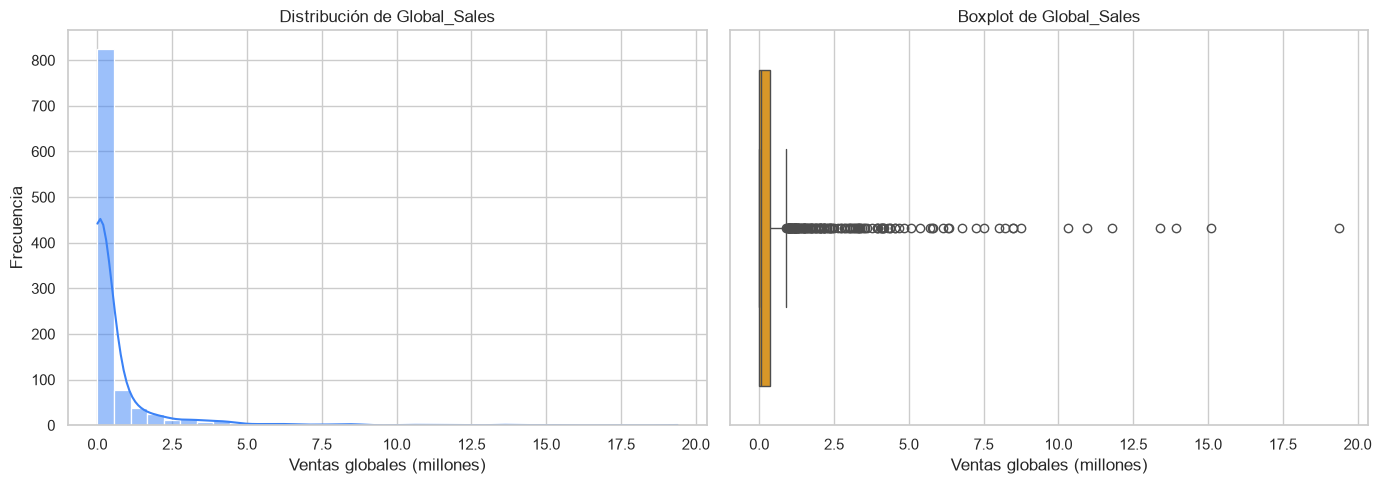

In [48]:
# Distribución de la variable dependiente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(dataset[target], bins=35, kde=True, ax=axes[0], color='#3B82F6')
axes[0].set_title('Distribución de Global_Sales')
axes[0].set_xlabel('Ventas globales (millones)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=dataset[target], ax=axes[1], color='#F59E0B')
axes[1].set_title('Boxplot de Global_Sales')
axes[1].set_xlabel('Ventas globales (millones)')

plt.tight_layout()
plt.show()


**Interpretación:** `Global_Sales` concentra muchos juegos con ventas bajas y pocos superventas. Estos atípicos pueden influir en el entrenamiento y en las métricas.


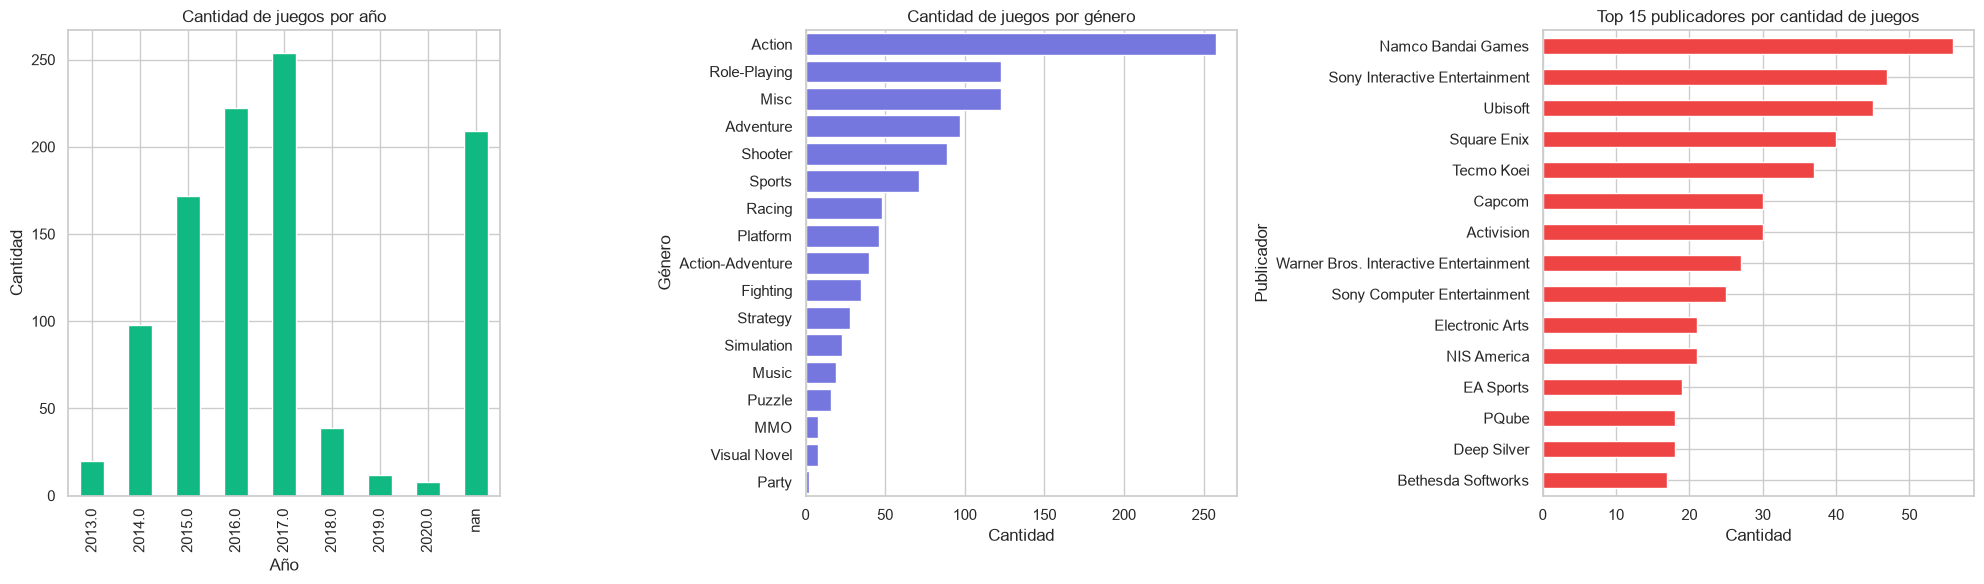

In [49]:
# Distribución de variables categóricas y año
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

dataset['Year'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[0], color='#10B981')
axes[0].set_title('Cantidad de juegos por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

genre_order = dataset['Genre'].value_counts().index
sns.countplot(data=dataset, y='Genre', order=genre_order, ax=axes[1], color='#6366F1')
axes[1].set_title('Cantidad de juegos por género')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Género')

top_publishers = dataset['Publisher'].value_counts().head(15).sort_values()
top_publishers.plot(kind='barh', ax=axes[2], color='#EF4444')
axes[2].set_title('Top 15 publicadores por cantidad de juegos')
axes[2].set_xlabel('Cantidad')
axes[2].set_ylabel('Publicador')

plt.tight_layout()
plt.show()


**Interpretación:** algunos años, géneros y publicadores tienen más registros que otros. Esto puede afectar el aprendizaje de categorías poco representadas.


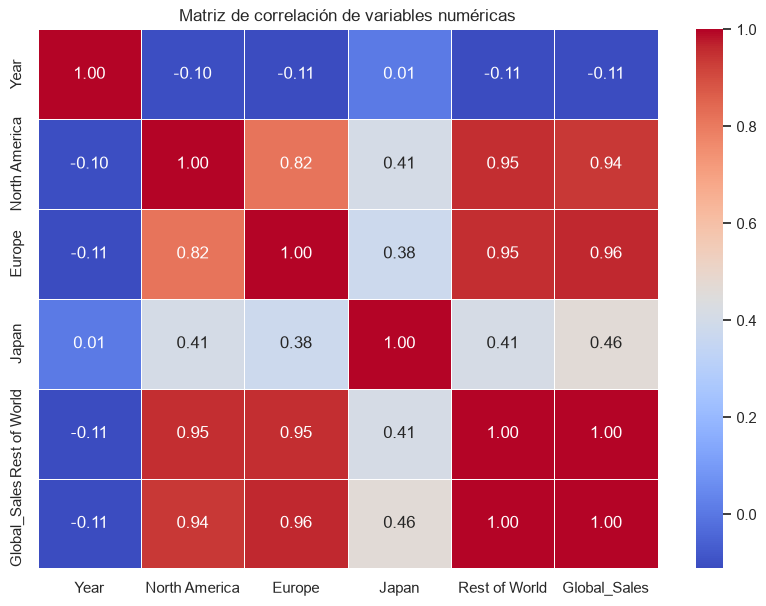

Global_Sales     1.0000
Rest of World    0.9972
Europe           0.9622
North America    0.9385
Japan            0.4637
Year            -0.1075
Name: Global_Sales, dtype: float64

In [50]:
# Matriz de correlación de variables numéricas
corr_cols = ['Year'] + sales_cols
corr_matrix = dataset[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

corr_matrix[target].sort_values(ascending=False)


**Interpretación:** las ventas regionales se relacionan fuertemente con `Global_Sales`. `Year` suele tener una relación más débil con las ventas totales.


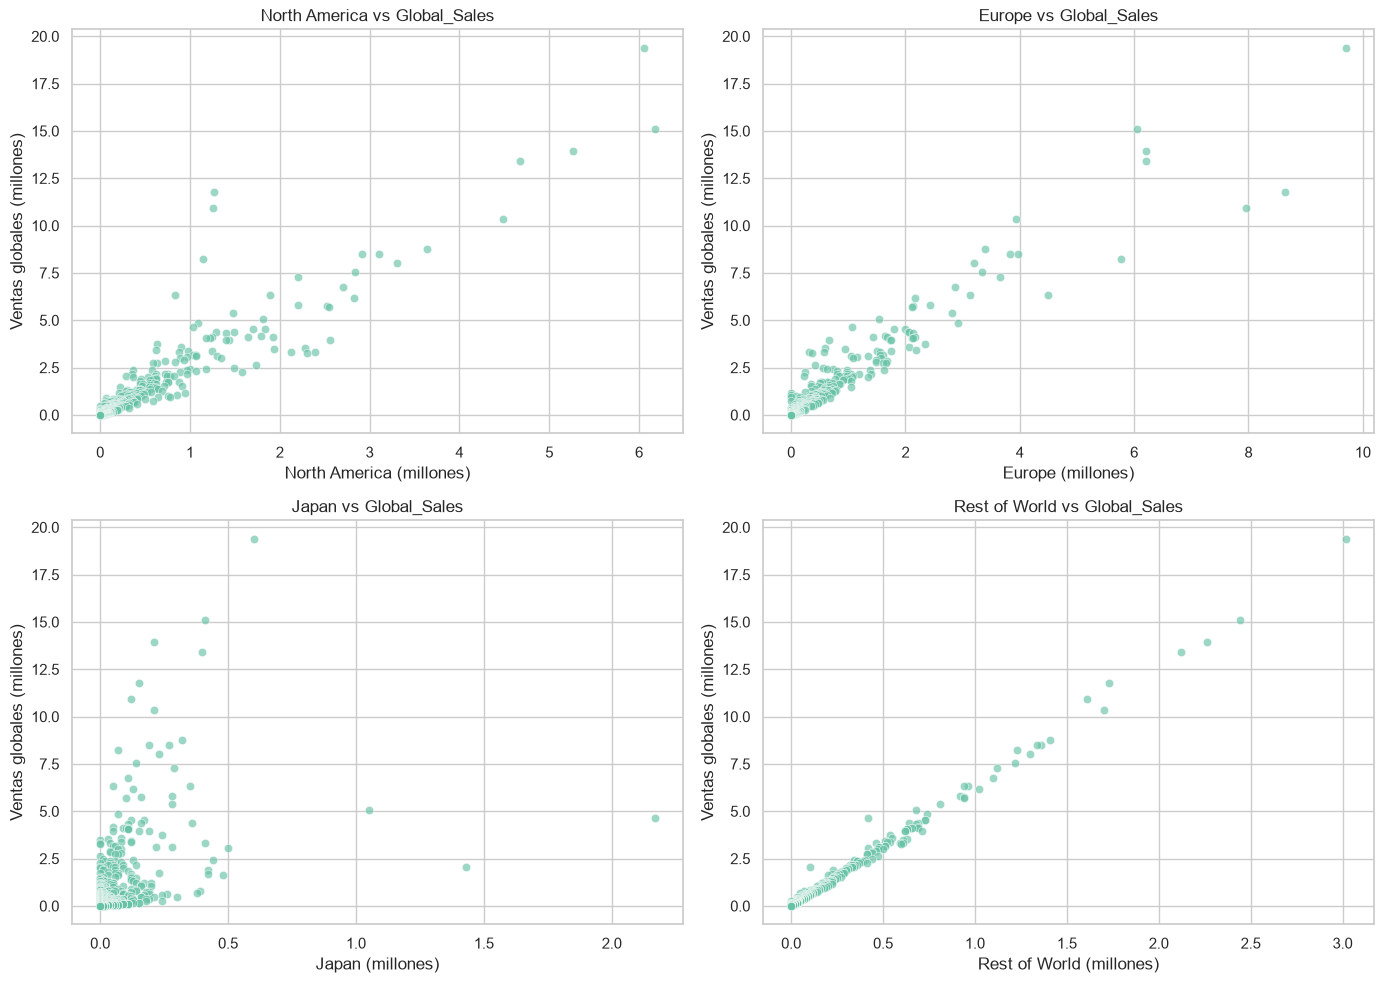

In [51]:
# Relaciones entre ventas regionales y variable dependiente
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, regional_sales_cols):
    sns.scatterplot(data=dataset, x=col, y=target, ax=ax, alpha=0.65)
    ax.set_title(f'{col} vs {target}')
    ax.set_xlabel(f'{col} (millones)')
    ax.set_ylabel('Ventas globales (millones)')

plt.tight_layout()
plt.show()


**Interpretacion:** al aumentar las ventas regionales tambien aumenta `Global_Sales`. Esta relacion es la base del enfoque final: estimar el total global a partir de ventas regionales observadas.


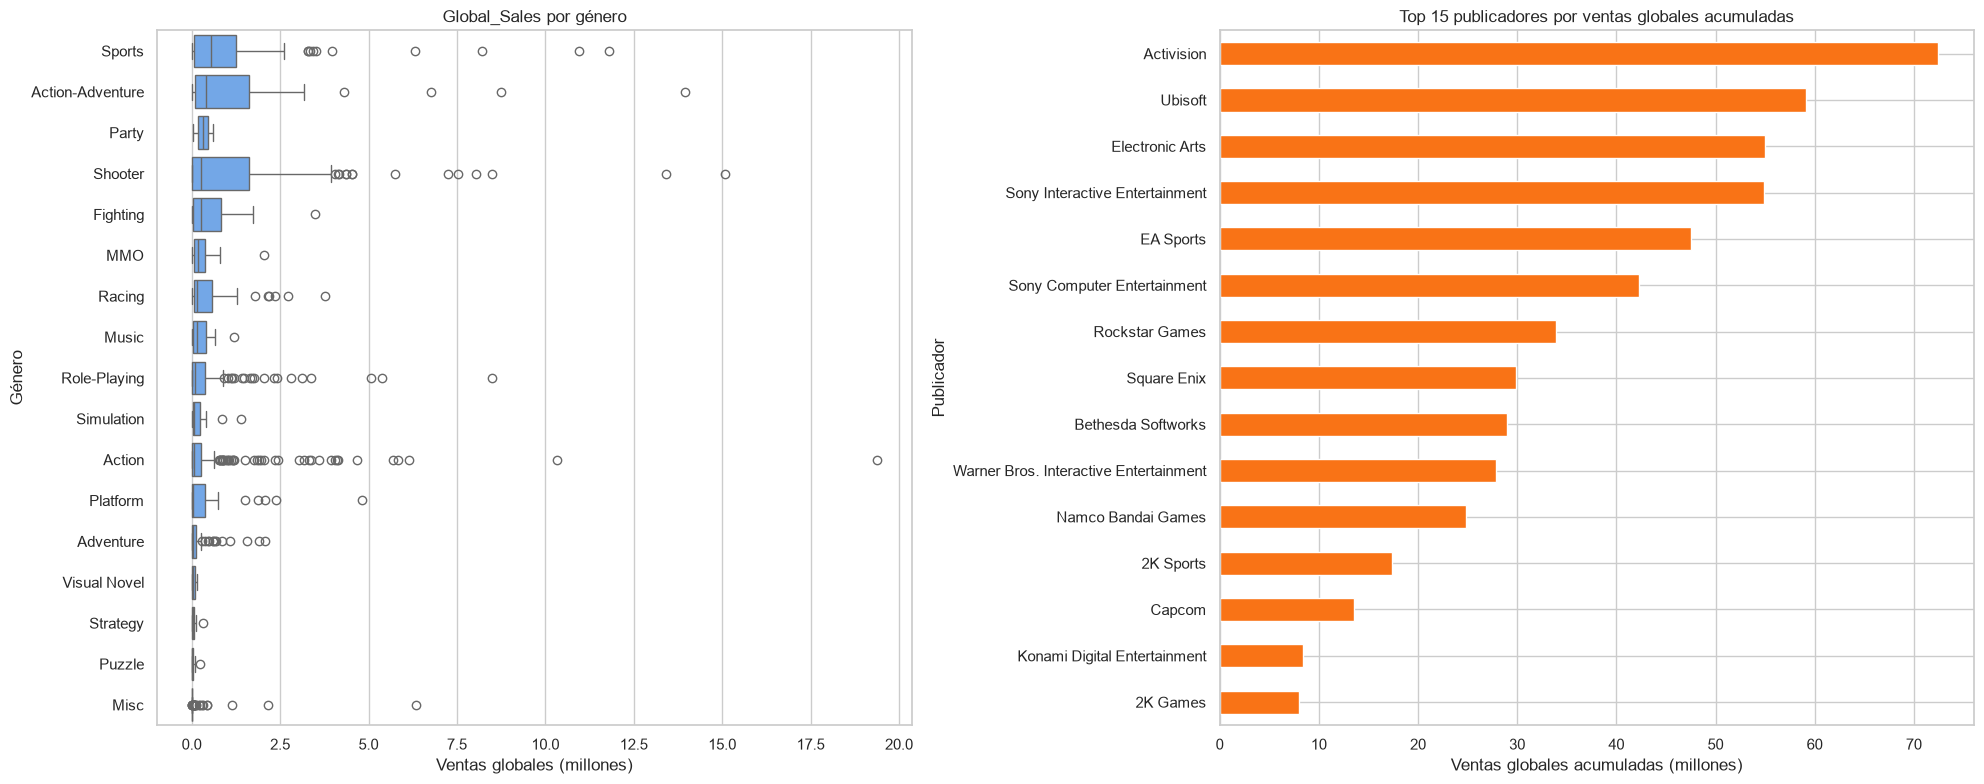

In [52]:
# Relación entre variables categóricas y Global_Sales
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

genre_order_by_median = dataset.groupby('Genre')[target].median().sort_values(ascending=False).index
sns.boxplot(data=dataset, x=target, y='Genre', order=genre_order_by_median, ax=axes[0], color='#60A5FA')
axes[0].set_title('Global_Sales por género')
axes[0].set_xlabel('Ventas globales (millones)')
axes[0].set_ylabel('Género')

top_publishers_by_sales = dataset.groupby('Publisher')[target].sum().sort_values(ascending=False).head(15).sort_values()
top_publishers_by_sales.plot(kind='barh', ax=axes[1], color='#F97316')
axes[1].set_title('Top 15 publicadores por ventas globales acumuladas')
axes[1].set_xlabel('Ventas globales acumuladas (millones)')
axes[1].set_ylabel('Publicador')

plt.tight_layout()
plt.show()


**Interpretación:** géneros y publicadores muestran diferencias en ventas. Estas variables requieren codificación antes de entrenar modelos.


## 3.3 Preparación de los datos

En esta etapa se define `X` y `y`, se eliminan columnas no adecuadas para predecir, y se prepara un flujo de imputación, codificación y escalado sin ajustar transformaciones con datos de prueba.


### Definicion de X y y

- `y`: variable dependiente `Global_Sales`, ventas globales en millones de copias.
- `X`: variables independientes originales usadas para estimar el total global: `Year`, `Genre`, `Publisher` y ventas regionales observadas.

`Global_Sales` es numerica continua porque puede tomar valores decimales de ventas, por ejemplo 0.06, 1.50 o 19.39 millones. Por ello, el problema corresponde a regresion.

El proyecto se interpreta como estimacion del total global con ventas regionales ya observadas, no como prediccion previa al lanzamiento.


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = 'Global_Sales'

identifier_cols = ['Game']
removed_columns = identifier_cols

feature_cols = [col for col in dataset.columns if col not in removed_columns + [target]]

X = dataset[feature_cols].copy()
y = dataset[target].copy()

removed_columns_report = pd.DataFrame({
    'Columna eliminada': removed_columns,
    'Motivo': [
        'Identificador del videojuego; alta unicidad y riesgo de sobreajuste si se codifica directamente.'
    ]
})

input_features_report = pd.DataFrame({
    'Variable en X': feature_cols,
    'Uso': [
        'Anio de lanzamiento.',
        'Categoria nominal del videojuego.',
        'Empresa publicadora.',
        'Ventas observadas en Norteamerica.',
        'Ventas observadas en Europa.',
        'Ventas observadas en Japon.',
        'Ventas observadas en resto del mundo.'
    ]
})

print(f'X: {X.shape}')
print(f'y: {y.shape}')
display(X.head())
display(y.describe())
display(input_features_report)
display(removed_columns_report)


X: (1034, 7)
y: (1034,)


,Year,Genre,Publisher,North America,Europe,Japan,Rest of World
0,2014.0000,Action,Rockstar Games,6.0600,9.7100,0.6000,3.0200
1,2015.0000,Shooter,Activision,6.1800,6.0500,0.4100,2.4400
2,2018.0000,Action-Adventure,Rockstar Games,5.2600,6.2100,0.2100,2.2600
3,2017.0000,Shooter,Activision,4.6700,6.2100,0.4000,2.1200
4,2017.0000,Sports,EA Sports,1.2700,8.6400,0.1500,1.7300


count   1034.0000
mean       0.5761
std        1.5835
min        0.0000
25%        0.0000
50%        0.0600
75%        0.3575
max       19.3900
Name: Global_Sales, dtype: float64

,Variable en X,Uso
0,Year,Anio de lanzamiento.
1,Genre,Categoria nominal del videojuego.
2,Publisher,Empresa publicadora.
3,North America,Ventas observadas en Norteamerica.
4,Europe,Ventas observadas en Europa.
5,Japan,Ventas observadas en Japon.
6,Rest of World,Ventas observadas en resto del mundo.


,Columna eliminada,Motivo
0,Game,Identificador del videojuego; alta unicidad y ...


**Justificacion:** Game se elimina por ser identificador. Las ventas regionales se conservan porque el proyecto estima Global_Sales a partir de ventas regionales observadas.


### Tratamiento de valores faltantes

Se identifican los nulos solo en las variables independientes. La variable objetivo no se modifica.


In [54]:
missing_X = pd.DataFrame({
    'Nulos': X.isna().sum(),
    'Porcentaje': (X.isna().mean() * 100).round(2)
}).sort_values('Nulos', ascending=False)

missing_X


,Nulos,Porcentaje
Year,209,20.2100
Publisher,209,20.2100
Genre,0,0.0000
North America,0,0.0000
Europe,0,0.0000
Japan,0,0.0000
Rest of World,0,0.0000


In [55]:
imputation_plan = pd.DataFrame({
    'Variable': ['Year', 'Genre', 'Publisher'],
    'Tipo': ['Discreta numérica', 'Nominal', 'Nominal'],
    'Técnica': ['Mediana', 'Constante: Unknown', 'Constante: Unknown'],
    'Justificación': [
        'La mediana es robusta y mantiene un año representativo sin verse afectada por extremos.',
        'No tiene nulos, pero el pipeline queda preparado si aparecen nuevos datos faltantes.',
        'Evita asignar los publicadores faltantes al publicador más frecuente.'
    ]
})

imputation_plan


,Variable,Tipo,Técnica,Justificación
0,Year,Discreta numérica,Mediana,La mediana es robusta y mantiene un año repres...
1,Genre,Nominal,Constante: Unknown,"No tiene nulos, pero el pipeline queda prepara..."
2,Publisher,Nominal,Constante: Unknown,Evita asignar los publicadores faltantes al pu...


**Efecto esperado:** después de la imputación no deben quedar nulos en `X`. La imputación se aplicará dentro del pipeline y se ajustará solo con el conjunto de entrenamiento.


### Conversión de variables categóricas

`Genre` y `Publisher` son variables nominales, por lo que se usa `OneHotEncoder`. No se usa codificación ordinal porque asignaría un orden artificial entre géneros o publicadores.


### Escalado

`Year` se escala con `StandardScaler`. Esto es útil para PCA y modelos sensibles a escala o distancia. Las variables one-hot no se escalan porque ya quedan en 0 y 1. Los árboles no requieren escalado, pero usar el mismo preprocesamiento facilita comparar modelos.


In [56]:
numeric_features = ['Year', 'North America', 'Europe', 'Japan', 'Rest of World']
categorical_features = ['Genre', 'Publisher']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
], remainder='drop', verbose_feature_names_out=False)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

prepared_feature_names = preprocessor.get_feature_names_out()

X_train_prepared = pd.DataFrame(X_train_prepared, columns=prepared_feature_names, index=X_train.index)
X_test_prepared = pd.DataFrame(X_test_prepared, columns=prepared_feature_names, index=X_test.index)

print(f'Columnas antes de preparar X: {X.shape[1]}')
print(f'Columnas despues de preparar X_train: {X_train_prepared.shape[1]}')
print(f'Nulos en X_train preparado: {int(X_train_prepared.isna().sum().sum())}')
print(f'Nulos en X_test preparado: {int(X_test_prepared.isna().sum().sum())}')

X_train_prepared.head()


Columnas antes de preparar X: 7
Columnas despues de preparar X_train: 157
Nulos en X_train preparado: 0
Nulos en X_test preparado: 0


,Year,North America,Europe,Japan,Rest of World,Genre_Action,Genre_Action-Adventure,Genre_Adventure,Genre_Fighting,Genre_MMO,Genre_Misc,Genre_Music,Genre_Party,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Genre_Visual Novel,Publisher_2K Games,Publisher_2K Sports,Publisher_3D Realms,Publisher_505 Games,Publisher_5pb,Publisher_Acquire,Publisher_Active Gaming Media,Publisher_Activision,Publisher_Aksys Games,Publisher_Arc System Works,Publisher_Astragon,Publisher_Atari,Publisher_Atlus,Publisher_Avanquest,Publisher_Badland Studio,Publisher_Bandai Namco Entertainment,Publisher_Bandai Namco Games,Publisher_Bethesda Softworks,Publisher_Big Ben Interactive,Publisher_Bigben Interactive,Publisher_BioWare,Publisher_CD Projekt Red Studio,Publisher_Capcom,Publisher_Codemasters,Publisher_CokeM Interactive,Publisher_Compile Heart,Publisher_Compulsion Games,Publisher_D3Publisher,Publisher_DMM Games,Publisher_DTP Entertainment,Publisher_Daedalic Entertainment,Publisher_Deep Silver,Publisher_Disney Interactive Studios,Publisher_Double Damage Games,Publisher_Dusenberry Martin Racing,Publisher_EA Sports,Publisher_Electronic Arts,Publisher_Endnight Games LtdÊ,Publisher_Focus Home Interactive,Publisher_Frictional Games,Publisher_Frontier Developments,Publisher_Funbox Media,Publisher_Gaijinworks,Publisher_GameMill,Publisher_GameMill Entertainment,Publisher_GameTrust,Publisher_Games Workshop,Publisher_Gearbox Software,Publisher_Grey Box,Publisher_Gun Media,Publisher_GungHo,Publisher_Gunho Online Entertainment,Publisher_Gust,Publisher_Harmonix Music Systems,Publisher_Idea Factory International,Publisher_Insomniac Games,Publisher_Introversion Software,Publisher_Kadokawa Games,Publisher_Kalypso Media,Publisher_Koch Media,Publisher_Konami Digital Entertainment,Publisher_Level 5,Publisher_Little Orbit,Publisher_M2,Publisher_MLB.com,Publisher_Marvelous Interactive,Publisher_Maximum Games,Publisher_Merge Games,Publisher_Microids,Publisher_Milestone S.r.l,Publisher_Milestone S.r.l.,Publisher_Mojang,Publisher_NIS America,Publisher_Namco Bandai Games,Publisher_Nicalis,Publisher_Nighthawk Interactive,Publisher_Nihon Falcom Corporation,Publisher_Nippon Ichi Software,Publisher_Nordic Games,Publisher_Nowhere Studios,Publisher_Outright Games,Publisher_PM Studios,Publisher_PQube,Publisher_Paradox InteractiveÊ,Publisher_Perfect World Entertainment,Publisher_Perp Games,Publisher_Rain Games,Publisher_Ravenscourt,Publisher_Rebellion,Publisher_Rebellion Developments,Publisher_Renegade Kid,Publisher_Revolution Software,Publisher_Rising Star Games,Publisher_Rockstar Games,Publisher_Sega,Publisher_Sinxsoft,Publisher_Soedesco,Publisher_Sold Out,Publisher_Sony Computer Entertainment,Publisher_Sony Interactive Entertainment,Publisher_Sony Online Entertainment,Publisher_Spike Chunsoft,Publisher_Sprite,Publisher_Square Enix,Publisher_Stainless Games,Publisher_Studio Wildcard,Publisher_System 3,Publisher_THQ Nordic,Publisher_Take-Two Interactive,Publisher_Taleworlds,Publisher_Tammeka Games,Publisher_Team Meat,Publisher_Team17 Digital Ltd,Publisher_Team17 Software,Publisher_Techland,Publisher_Tecmo Koei,Publisher_Telltale Games,Publisher_The Astronauts,"Publisher_Thekla, Inc.",Publisher_TopWare Interactive,Publisher_Triniti Interactive,Publisher_Tripwire Interactive,Publisher_Tru Blu Entertainment,Publisher_Two Tribes,Publisher_UIG Entertainment,Publisher_Ubisoft,Publisher_Unknown,Publisher_Versus Evil,Publisher_Wander MMO,Publisher_Warner Bros. Interactive,Publisher_Warner Bros. Interactive Entertainment,Publisher_Wired Productions,Publisher_Xseed Games,Publisher_Yacht Club Games,Publisher_Yeti
518,-0.8442,-0.3634,-0.3115,0.2247,-0.3563,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00

In [57]:
encoder = preprocessor.named_transformers_['categorical'].named_steps['encoder']

encoding_report = pd.DataFrame({
    'Variable categórica': categorical_features,
    'Tipo': ['Nominal', 'Nominal'],
    'Técnica': ['OneHotEncoder', 'OneHotEncoder'],
    'Columnas generadas': [len(categories) for categories in encoder.categories_],
    'Justificación': [
        'Representa géneros sin imponer jerarquía.',
        'Representa publicadores sin imponer jerarquía.'
    ]
})

display(encoding_report)
display(pd.DataFrame({
    'Etapa': ['Antes de codificar', 'Después de imputar, codificar y escalar'],
    'Número de columnas': [X.shape[1], X_train_prepared.shape[1]]
}))


,Variable categórica,Tipo,Técnica,Columnas generadas,Justificación
0,Genre,Nominal,OneHotEncoder,17,Representa géneros sin imponer jerarquía.
1,Publisher,Nominal,OneHotEncoder,135,Representa publicadores sin imponer jerarquía.


,Etapa,Número de columnas
0,Antes de codificar,7
1,"Después de imputar, codificar y escalar",157


### Resultado de la preparacion

La preparacion queda definida con un `ColumnTransformer`: imputa y escala `Year` y las ventas regionales, imputa categoricas faltantes como `Unknown` y codifica `Genre` y `Publisher` con one-hot. El ajuste se realiza con `X_train` y solo se transforma `X_test`, evitando usar informacion del conjunto de prueba.


## 3.4 Selección y transformación de características

Se construyen dos representaciones de los datos: una con características seleccionadas y otra con componentes principales. Ambas parten de los datos ya preparados para evitar nulos, variables categóricas sin codificar y escalas incompatibles.


### Escenario 1: características seleccionadas

La selección final se hará con tres criterios: correlación con `y`, RFE e importancia mediante árboles. La correlación no se usa como único criterio porque solo mide relaciones lineales y no captura interacciones o relaciones no lineales.


#### Matriz de correlación

Se calcula la correlación entre cada característica preparada y `Global_Sales`, usando solo el conjunto de entrenamiento.


In [58]:
corr_with_target = X_train_prepared.apply(lambda col: col.corr(y_train)).fillna(0)

correlation_table = pd.DataFrame({
    'Característica': corr_with_target.index,
    'Correlación con y': corr_with_target.values,
    'Correlación absoluta': corr_with_target.abs().values
}).sort_values('Correlación absoluta', ascending=False)

display(correlation_table.head(15))
display(correlation_table.tail(10))


,Característica,Correlación con y,Correlación absoluta
4,Rest of World,0.9968,0.9968
2,Europe,0.9577,0.9577
1,North America,0.9327,0.9327
3,Japan,0.4600,0.4600
115,Publisher_Rockstar Games,0.2972,0.2972
58,Publisher_Electronic Arts,0.2054,0.2054
148,Publisher_Unknown,-0.1891,0.1891
17,Genre_Shooter,0.1822,0.1822
29,Publisher_Activision,0.1752,0.1752
57,Publisher_EA Sports,0.1615,0.1615


,Característica,Correlación con y,Correlación absoluta
143,Publisher_Tripwire Interactive,-0.0066,0.0066
45,Publisher_Codemasters,-0.0066,0.0066
127,Publisher_Studio Wildcard,0.0054,0.0054
8,Genre_Fighting,0.0048,0.0048
9,Genre_MMO,-0.0046,0.0046
54,Publisher_Disney Interactive Studios,0.0041,0.0041
38,Publisher_Bandai Namco Games,0.0023,0.0023
71,Publisher_Gun Media,-0.0019,0.0019
111,Publisher_Rebellion Developments,-0.0004,0.0004
75,Publisher_Harmonix Music Systems,0.0001,0.0001


In [59]:
feature_corr_matrix = X_train_prepared.corr().abs()
upper_triangle = feature_corr_matrix.where(np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool))

high_feature_corr = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Característica 1', 'level_1': 'Característica 2', 0: 'Correlación absoluta'})
    .sort_values('Correlación absoluta', ascending=False)
)

high_feature_corr[high_feature_corr['Correlación absoluta'] >= 0.80].head(10)


,Característica 1,Característica 2,Correlación absoluta
161,North America,Rest of World,0.9492
318,Europe,Rest of World,0.9469


**Interpretación:** las correlaciones positivas indican características asociadas con mayores ventas; las negativas, con menores ventas. Algunas variables pueden tener poca relación lineal, pero aun así ser útiles en modelos no lineales. Las variables one-hot de una misma columna pueden presentar dependencia entre sí, por lo que también se revisa posible multicolinealidad.


#### Recursive Feature Elimination, RFE

Se aplica RFE con `LinearRegression`. Este estimador es compatible porque genera coeficientes (`coef_`) que RFE usa para eliminar características de menor contribución.


In [60]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

n_selected_features = 6
rfe_estimator = LinearRegression()
rfe = RFE(estimator=rfe_estimator, n_features_to_select=n_selected_features)
rfe.fit(X_train_prepared, y_train)

rfe_table = pd.DataFrame({
    'Característica': X_train_prepared.columns,
    'Ranking RFE': rfe.ranking_,
    'Seleccionada por RFE': rfe.support_
}).sort_values(['Ranking RFE', 'Característica'])

display(rfe_table.head(20))

rfe_selected_features = rfe_table.loc[rfe_table['Seleccionada por RFE'], 'Característica'].tolist()
rfe_discarded_features = rfe_table.loc[~rfe_table['Seleccionada por RFE'], 'Característica'].tolist()

print('Características seleccionadas por RFE:')
print(rfe_selected_features)
print('\nNúmero de características descartadas por RFE:', len(rfe_discarded_features))


,Característica,Ranking RFE,Seleccionada por RFE
2,Europe,1,True
3,Japan,1,True
1,North America,1,True
71,Publisher_Gun Media,1,True
127,Publisher_Studio Wildcard,1,True
4,Rest of World,1,True
135,Publisher_Team17 Software,2,False
133,Publisher_Team Meat,3,False
87,Publisher_Marvelous Interactive,4,False
110,Publisher_Rebellion,5,False


Características seleccionadas por RFE:
['Europe', 'Japan', 'North America', 'Publisher_Gun Media', 'Publisher_Studio Wildcard', 'Rest of World']

Número de características descartadas por RFE: 151


#### Importancia mediante árboles

Se utiliza `RandomForestRegressor` porque captura relaciones no lineales y entrega importancias de características mediante `feature_importances_`.


In [61]:
from sklearn.ensemble import RandomForestRegressor

tree_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
tree_model.fit(X_train_prepared, y_train)

tree_importance_table = pd.DataFrame({
    'Característica': X_train_prepared.columns,
    'Importancia en árboles': tree_model.feature_importances_
}).sort_values('Importancia en árboles', ascending=False)

display(tree_importance_table.head(15))


,Característica,Importancia en árboles
4,Rest of World,0.9118
2,Europe,0.0634
1,North America,0.0129
3,Japan,0.0090
0,Year,0.0019
19,Genre_Sports,0.0002
121,Publisher_Sony Interactive Entertainment,0.0002
17,Genre_Shooter,0.0002
5,Genre_Action,0.0001
16,Genre_Role-Playing,0.0001


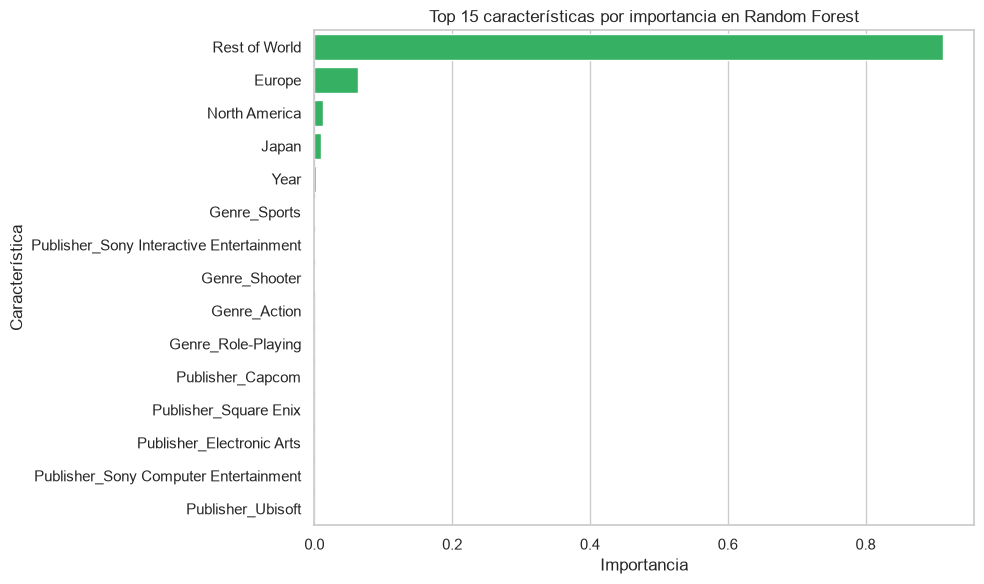

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tree_importance_table.head(15),
    x='Importancia en árboles',
    y='Característica',
    color='#22C55E'
)
plt.title('Top 15 características por importancia en Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()


**Interpretación:** las importancias de árboles permiten detectar características útiles aunque su relación con `Global_Sales` no sea estrictamente lineal. Estos resultados se comparan con correlación y RFE para elegir una selección final equilibrada.


#### Selección final

Se integran los tres métodos. Una característica se favorece si aparece bien posicionada en al menos dos criterios, o si tiene una importancia alta en árboles y aporta información interpretable.


In [63]:
selection_comparison = (
    correlation_table[['Característica', 'Correlación con y', 'Correlación absoluta']]
    .merge(rfe_table[['Característica', 'Ranking RFE', 'Seleccionada por RFE']], on='Característica')
    .merge(tree_importance_table, on='Característica')
)

selection_comparison['Top correlación'] = selection_comparison['Correlación absoluta'].rank(ascending=False, method='min') <= 15
selection_comparison['Top árboles'] = selection_comparison['Importancia en árboles'].rank(ascending=False, method='min') <= 15
selection_comparison['Puntaje conjunto'] = (
    selection_comparison['Top correlación'].astype(int)
    + selection_comparison['Seleccionada por RFE'].astype(int)
    + selection_comparison['Top árboles'].astype(int)
)

selection_comparison = selection_comparison.sort_values(
    ['Puntaje conjunto', 'Importancia en árboles', 'Correlación absoluta'],
    ascending=[False, False, False]
)

selected_features = selection_comparison.head(n_selected_features)['Característica'].tolist()

selection_comparison['Decisión'] = np.where(
    selection_comparison['Característica'].isin(selected_features),
    'Incluir',
    'Excluir'
)
selection_comparison['Resultado'] = np.where(
    selection_comparison['Característica'].isin(selected_features),
    'Seleccionada',
    'No seleccionada'
)

final_selection_table = selection_comparison[[
    'Característica', 'Correlación con y', 'Ranking RFE', 'Seleccionada por RFE',
    'Importancia en árboles', 'Resultado', 'Decisión'
]]

display(final_selection_table.head(20))
print('Selección final:')
print(selected_features)


,Característica,Correlación con y,Ranking RFE,Seleccionada por RFE,Importancia en árboles,Resultado,Decisión
0,Rest of World,0.9968,1,True,0.9118,Seleccionada,Incluir
1,Europe,0.9577,1,True,0.0634,Seleccionada,Incluir
2,North America,0.9327,1,True,0.0129,Seleccionada,Incluir
3,Japan,0.4600,1,True,0.0090,Seleccionada,Incluir
11,Year,-0.1285,127,False,0.0019,Seleccionada,Incluir
10,Genre_Sports,0.1323,147,False,0.0002,Seleccionada,Incluir
7,Genre_Shooter,0.1822,133,False,0.0002,No seleccionada,Excluir
5,Publisher_Electronic Arts,0.2054,151,False,0.0000,No seleccionada,Excluir
12,Publisher_Sony Computer Entertainment,0.1191,142,False,0.0000,No seleccionada,Excluir
13,Publisher_Ubisoft,0.1157,36,False,0.0000,No seleccionada,Excluir


Selección final:
['Rest of World', 'Europe', 'North America', 'Japan', 'Year', 'Genre_Sports']


**Criterio final:** se incluyen entre cuatro y seis características con mejor evidencia conjunta. Se excluyen las demás por baja correlación, bajo ranking RFE, baja importancia en árboles o información redundante. Si los métodos difieren, se prioriza la coincidencia entre métodos y la importancia en árboles para capturar relaciones no lineales.


In [64]:
X_train_selected = X_train_prepared[selected_features].copy()
X_test_selected = X_test_prepared[selected_features].copy()

print(f'X_train_selected: {X_train_selected.shape}')
print(f'X_test_selected: {X_test_selected.shape}')
X_train_selected.head()


X_train_selected: (827, 6)
X_test_selected: (207, 6)


,Rest of World,Europe,North America,Japan,Year,Genre_Sports
518,-0.3563,-0.3115,-0.3634,0.2247,-0.8442,0.0000
355,-0.2341,-0.3115,-0.1141,-0.2929,0.0296,0.0000
528,-0.3156,-0.3115,-0.2743,-0.2929,1.7773,0.0000
445,-0.2748,-0.3115,-0.2209,-0.2929,0.9034,0.0000
986,-0.3563,-0.3115,-0.3634,-0.2929,0.0296,0.0000


### Escenario 2: Análisis de Componentes Principales, PCA

PCA se aplica después de imputar, codificar y escalar. Para evitar fuga de información, se incorpora en un pipeline y se ajusta únicamente con `X_train`.


In [65]:
from sklearn.decomposition import PCA

pca_analysis_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=42))
])

pca_analysis_pipeline.fit(X_train, y_train)
pca_model = pca_analysis_pipeline.named_steps['pca']

explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

pca_variance_table = pd.DataFrame({
    'Componente': np.arange(1, len(explained_variance) + 1),
    'Varianza explicada': explained_variance,
    'Varianza acumulada': cumulative_variance
})

print(f'Número de variables antes de PCA: {X_train_prepared.shape[1]}')
print(f'Número de componentes generados: {len(explained_variance)}')
print(f'Componentes conservados para explicar al menos 95%: {n_components_95}')
display(pca_variance_table.head(20))


Número de variables antes de PCA: 157
Número de componentes generados: 157
Componentes conservados para explicar al menos 95%: 33


,Componente,Varianza explicada,Varianza acumulada
0,1,0.4488,0.4488
1,2,0.1491,0.5979
2,3,0.1114,0.7092
3,4,0.0316,0.7408
4,5,0.0303,0.7712
5,6,0.0269,0.7981
6,7,0.0166,0.8147
7,8,0.0147,0.8294
8,9,0.0121,0.8414
9,10,0.0114,0.8528


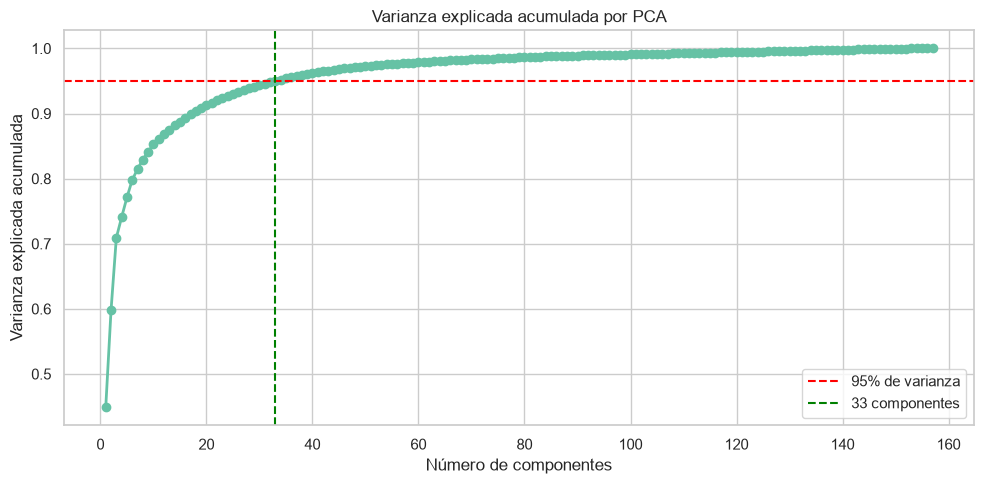

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(pca_variance_table['Componente'], pca_variance_table['Varianza acumulada'], marker='o', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% de varianza')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} componentes')
plt.title('Varianza explicada acumulada por PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=n_components_95, random_state=42))
])

X_train_pca = pca_pipeline.fit_transform(X_train, y_train)
X_test_pca = pca_pipeline.transform(X_test)

pca_columns = [f'PC{i}' for i in range(1, n_components_95 + 1)]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train.index)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test.index)

dimensionality_reduction = pd.DataFrame({
    'Representación': ['Antes de PCA', 'Después de PCA'],
    'Número de columnas': [X_train_prepared.shape[1], X_train_pca.shape[1]]
})

display(dimensionality_reduction)
X_train_pca.head()


,Representación,Número de columnas
0,Antes de PCA,157
1,Después de PCA,33


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
518,-0.3994,-0.6433,0.7641,-0.1712,-0.2155,-0.5534,0.8446,0.0454,-0.0782,-0.1477,-0.0548,0.7395,0.0691,0.1213,0.0512,0.1509,0.1151,-0.0359,-0.1541,0.0226,-0.0451,-0.0701,0.0020,-0.1221,-0.0387,0.0357,0.0040,0.0190,-0.0012,-0.0232,-0.0093,0.0487,-0.0018
355,-0.4248,-0.0721,-0.1344,0.8263,0.0746,0.1248,0.0186,-0.0432,0.0467,-0.1130,-0.0639,-0.0394,-0.0725,-0.0677,-0.0826,0.0007,-0.1365,-0.0471,-0.1748,0.2828,-0.1128,0.1828,0.7482,0.2164,-0.0700,0.2355,-0.2194,-0.0372,-0.0139,0.0079,0.0203,-0.0141,0.0262
528,-0.7527,1.5816,-0.6916,0.7580,0.2211,0.0845,-0.0196,-0.0931,-0.0342,-0.0173,-0.1265,-0.0196,0.0038,-0.0678,-0.1158,-0.0146,-0.0605,-0.0006,-0.0815,0.0419,-0.0595,0.0126,-0.0170,0.1112,0.0778,-0.0059,0.0423,-0.0645,0.0402,-0.0952,-0.0117,-0.1414,-0.0028
445,-0.5784,0.7432,-0.4538,-0.1036,-0.2572,-0.2175,-0.2546,-0.0273,0.9004,-0.1116,-0.3946,0.0376,-0.0469,-0.0325,-0.0803,-0.0127,-0.0630,-0.0039,-0.0549,-0.0524,-0.0368,-0.0743,-0.1057,-0.0099,-0.0919,-0.2158,0.2816,-0.0329,0.0163,-0.1868,-0.1984,0.0072,0.4941
986,-0.7105,-0.0820,-0.1072,-0.5097,0.0946,0.4552,-0.2732,0.9060,-0.2683,-0.0789,-0.0680,0.0296,0.0617,0.0371,0.0279,-0.0039,0.0481,-0.0074,-0.0320,-0.0324,0.0427,-0.0208,-0.0030,-0.0249,-0.0328,0.0503,-0.0327,-0.0229,0.0031,0.0017,-0.0056,0.0218,0.0272


**Justificación de PCA:** se conservan los componentes necesarios para explicar al menos 95% de la varianza. PCA reduce dimensionalidad y puede ayudar a modelos sensibles a escala o multicolinealidad. Su desventaja es que los componentes son combinaciones de variables, por lo que la interpretación del modelo se vuelve menos directa y puede perderse información de baja varianza.


## 3.5 Modelado

Se seleccionan tres algoritmos de regresión y se prueban en los dos escenarios definidos: características seleccionadas y PCA. Uno de los modelos es una red neuronal, como solicita el proyecto.


### Algoritmos seleccionados

Los tres algoritmos son diferentes entre sí: un modelo lineal, un modelo basado en árboles y una red neuronal.


In [68]:
algorithm_description = pd.DataFrame({
    'Algoritmo': ['Regresión Lineal', 'Random Forest Regressor', 'MLPRegressor'],
    'Funcionamiento general': [
        'Ajusta una relación lineal entre las características y la variable objetivo.',
        'Construye varios árboles de decisión y promedia sus predicciones.',
        'Red neuronal multicapa que aprende relaciones no lineales mediante neuronas y pesos.'
    ],
    'Parámetros principales': [
        'fit_intercept=True',
        'n_estimators=150, min_samples_leaf=2, random_state=42',
        'hidden_layer_sizes=(32,16), activation=relu, max_iter=600, early_stopping=True'
    ],
    'Justificación': [
        'Sirve como modelo base simple e interpretable.',
        'Captura relaciones no lineales y es robusto ante variables one-hot.',
        'Cumple el requisito de red neuronal y puede aprender patrones no lineales.'
    ],
    'Ventajas': [
        'Rápida, interpretable y fácil de comparar.',
        'Buen desempeño en problemas tabulares y poca necesidad de supuestos lineales.',
        'Flexible para relaciones complejas entre variables.'
    ],
    'Limitaciones': [
        'No captura bien relaciones no lineales.',
        'Menos interpretable y puede tardar más que un modelo lineal.',
        'Sensible a escala, hiperparámetros y tamaño del dataset.'
    ]
})

algorithm_description


,Algoritmo,Funcionamiento general,Parámetros principales,Justificación,Ventajas,Limitaciones
0,Regresión Lineal,Ajusta una relación lineal entre las caracterí...,fit_intercept=True,Sirve como modelo base simple e interpretable.,"Rápida, interpretable y fácil de comparar.",No captura bien relaciones no lineales.
1,Random Forest Regressor,Construye varios árboles de decisión y promedi...,"n_estimators=150, min_samples_leaf=2, random_s...",Captura relaciones no lineales y es robusto an...,Buen desempeño en problemas tabulares y poca n...,Menos interpretable y puede tardar más que un ...
2,MLPRegressor,Red neuronal multicapa que aprende relaciones ...,"hidden_layer_sizes=(32,16), activation=relu, m...",Cumple el requisito de red neuronal y puede ap...,Flexible para relaciones complejas entre varia...,"Sensible a escala, hiperparámetros y tamaño de..."


### Pipelines utilizados

Los seis experimentos usan la misma división de entrenamiento, la misma semilla y validación cruzada con 7 particiones. Los datos de prueba se conservan sin usarse para decidir parámetros.


In [69]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import KFold, cross_validate
from sklearn.neural_network import MLPRegressor

RANDOM_STATE = 42

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.reindex(columns=self.feature_names, fill_value=0)


model_definitions = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Red Neuronal MLP': MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=600,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

def build_selected_features_pipeline(model):
    selected_preprocessor = clone(preprocessor).set_output(transform='pandas')
    return Pipeline(steps=[
        ('preprocessor', selected_preprocessor),
        ('feature_selector', FeatureSelector(selected_features)),
        ('model', model)
    ])

def build_pca_model_pipeline(model):
    return Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('pca', PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
        ('model', model)
    ])

pipeline_description = pd.DataFrame({
    'Escenario': ['Características seleccionadas', 'PCA'],
    'Pipeline': [
        'preprocessor -> feature_selector -> modelo',
        'preprocessor -> PCA -> modelo'
    ],
    'Descripción': [
        'Usa las 6 características elegidas por correlación, RFE e importancia de árboles.',
        f'Usa {n_components_95} componentes principales ajustados dentro del pipeline.'
    ]
})

pipeline_description


,Escenario,Pipeline,Descripción
0,Características seleccionadas,preprocessor -> feature_selector -> modelo,Usa las 6 características elegidas por correla...
1,PCA,preprocessor -> PCA -> modelo,Usa 33 componentes principales ajustados dentr...


### Hiperparámetros

Los parámetros se fijan antes de evaluar con validación cruzada. No se usan los datos de prueba para elegir configuración.


In [70]:
hyperparameter_report = pd.DataFrame({
    'Algoritmo': ['Regresión Lineal', 'Random Forest', 'Red Neuronal MLP'],
    'Parámetros modificados': [
        'No se modifican parámetros relevantes.',
        'n_estimators=150, min_samples_leaf=2, random_state=42',
        'hidden_layer_sizes=(32,16), alpha=0.001, max_iter=600, early_stopping=True'
    ],
    'Razón': [
        'Se usa como línea base.',
        'Aumentar estabilidad y reducir sobreajuste en hojas muy pequeñas.',
        'Controlar complejidad, permitir convergencia y detener entrenamiento si no mejora.'
    ],
    'Cómo se evitó fuga': [
        'Configuración definida antes de usar el conjunto de prueba.',
        'Configuración definida antes de usar el conjunto de prueba.',
        'Configuración definida antes de usar el conjunto de prueba.'
    ]
})

hyperparameter_report


,Algoritmo,Parámetros modificados,Razón,Cómo se evitó fuga
0,Regresión Lineal,No se modifican parámetros relevantes.,Se usa como línea base.,Configuración definida antes de usar el conjun...
1,Random Forest,"n_estimators=150, min_samples_leaf=2, random_s...",Aumentar estabilidad y reducir sobreajuste en ...,Configuración definida antes de usar el conjun...
2,Red Neuronal MLP,"hidden_layer_sizes=(32,16), alpha=0.001, max_i...","Controlar complejidad, permitir convergencia y...",Configuración definida antes de usar el conjun...


### Validación cruzada de los seis experimentos

Se usa `KFold` con 7 particiones, `shuffle=True` y `random_state=42`. Las métricas son MAE, RMSE y R². También se registra el tiempo promedio de entrenamiento por partición.


In [71]:
cv_strategy = KFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

experiment_builders = {
    'Características seleccionadas': build_selected_features_pipeline,
    'PCA': build_pca_model_pipeline
}

experiment_results = []
experiment_pipelines = {}

for scenario_name, pipeline_builder in experiment_builders.items():
    for model_name, model in model_definitions.items():
        experiment_name = f'{scenario_name} - {model_name}'
        experiment_pipeline = pipeline_builder(clone(model))
        experiment_pipelines[experiment_name] = experiment_pipeline

        cv_scores = cross_validate(
            experiment_pipeline,
            X_train,
            y_train,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False
        )

        experiment_results.append({
            'Escenario': scenario_name,
            'Modelo': model_name,
            'Experimento': experiment_name,
            'MAE promedio': -cv_scores['test_MAE'].mean(),
            'RMSE promedio': -cv_scores['test_RMSE'].mean(),
            'R2 promedio': cv_scores['test_R2'].mean(),
            'Tiempo entrenamiento promedio (s)': cv_scores['fit_time'].mean()
        })

modeling_results = pd.DataFrame(experiment_results).sort_values('RMSE promedio')
modeling_results


,Escenario,Modelo,Experimento,MAE promedio,RMSE promedio,R2 promedio,Tiempo entrenamiento promedio (s)
0,Características seleccionadas,Regresión Lineal,Características seleccionadas - Regresión Lineal,0.0027,0.0045,1.0000,0.0161
3,PCA,Regresión Lineal,PCA - Regresión Lineal,0.0045,0.0069,1.0000,0.0460
2,Características seleccionadas,Red Neuronal MLP,Características seleccionadas - Red Neuronal MLP,0.0371,0.0771,0.9973,0.2194
5,PCA,Red Neuronal MLP,PCA - Red Neuronal MLP,0.0632,0.1100,0.9942,0.3339
1,Características seleccionadas,Random Forest,Características seleccionadas - Random Forest,0.0437,0.2057,0.9770,0.1964
4,PCA,Random Forest,PCA - Random Forest,0.0752,0.3243,0.9404,0.3457


**Condiciones equivalentes:** los seis experimentos usan `X_train`, `y_train`, las mismas 7 particiones, la misma semilla y las mismas métricas. El conjunto de prueba queda reservado para la evaluación final del mejor modelo.


## 3.6 Evaluación y comparación de los seis experimentos

Los seis experimentos se evalúan con `KFold(n_splits=7, shuffle=True, random_state=42)`. Se usan las mismas particiones, la misma semilla y las mismas métricas: R² y MAE.


### Validación cruzada

Se guardan los resultados de cada partición para calcular media, desviación estándar y varianza.


In [72]:
cv_detailed_rows = []
model_order = list(model_definitions.keys())

experiment_labels = {}
for scenario_name in experiment_builders.keys():
    for model_position, model_name in enumerate(model_order, start=1):
        if scenario_name == 'Características seleccionadas':
            label = f'Modelo {model_position} con características seleccionadas'
        else:
            label = f'Modelo {model_position} con PCA'
        experiment_labels[(scenario_name, model_name)] = label

for scenario_name, pipeline_builder in experiment_builders.items():
    for model_name, model in model_definitions.items():
        experiment_pipeline = pipeline_builder(clone(model))

        cv_scores = cross_validate(
            experiment_pipeline,
            X_train,
            y_train,
            cv=cv_strategy,
            scoring={'R2': 'r2', 'MAE': 'neg_mean_absolute_error'},
            n_jobs=1,
            return_train_score=False
        )

        for fold_index, (r2_value, mae_value, fit_time) in enumerate(
            zip(cv_scores['test_R2'], -cv_scores['test_MAE'], cv_scores['fit_time']),
            start=1
        ):
            cv_detailed_rows.append({
                'Escenario': scenario_name,
                'Modelo': model_name,
                'Experimento': experiment_labels[(scenario_name, model_name)],
                'Partición': fold_index,
                'R²': r2_value,
                'MAE': mae_value,
                'Tiempo entrenamiento (s)': fit_time
            })

cv_fold_results = pd.DataFrame(cv_detailed_rows)
cv_fold_results.head(10)


,Escenario,Modelo,Experimento,Partición,R²,MAE,Tiempo entrenamiento (s)
0,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,1,1.0000,0.0022,0.0184
1,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,2,1.0000,0.0028,0.0158
2,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,3,1.0000,0.0023,0.0162
3,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,4,1.0000,0.0028,0.0165
4,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,5,1.0000,0.0030,0.0163
5,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,6,1.0000,0.0030,0.0157
6,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,7,1.0000,0.0026,0.0159
7,Características seleccionadas,Random Forest,Modelo 2 con características seleccionadas,1,0.9962,0.0211,0.1965
8,Características seleccionadas,Random Forest,Modelo 2 con características seleccionadas,2,0.9971,0.0280,0.1998
9,Características seleccionadas,Random Forest,Modelo 2 con características seleccionadas,3,0.9976,0.0222,0.1825


In [73]:
cv_summary = (
    cv_fold_results
    .groupby(['Escenario', 'Modelo'], as_index=False)
    .agg(
        **{
            'R² medio': ('R²', 'mean'),
            'Desv. est. R²': ('R²', 'std'),
            'Varianza R²': ('R²', 'var'),
            'MAE medio': ('MAE', 'mean'),
            'Desv. est. MAE': ('MAE', 'std'),
            'Varianza MAE': ('MAE', 'var'),
            'Tiempo entrenamiento medio (s)': ('Tiempo entrenamiento (s)', 'mean')
        }
    )
)

cv_summary = cv_summary.sort_values(['R² medio', 'MAE medio'], ascending=[False, True])

selected_features_results = cv_summary[cv_summary['Escenario'] == 'Características seleccionadas'].copy()
pca_results = cv_summary[cv_summary['Escenario'] == 'PCA'].copy()
general_results = cv_summary[[
    'Escenario', 'Modelo', 'R² medio', 'Desv. est. R²', 'Varianza R²',
    'MAE medio', 'Desv. est. MAE', 'Varianza MAE'
]].copy()

display(selected_features_results)
display(pca_results)
display(general_results)


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo entrenamiento medio (s)
2,Características seleccionadas,Regresión Lineal,1.0000,0.0000,0.0000,0.0027,0.0003,0.0000,0.0164
1,Características seleccionadas,Red Neuronal MLP,0.9973,0.0018,0.0000,0.0371,0.0121,0.0001,0.1915
0,Características seleccionadas,Random Forest,0.9770,0.0375,0.0014,0.0437,0.0308,0.0009,0.2021


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo entrenamiento medio (s)
5,PCA,Regresión Lineal,1.0000,0.0000,0.0000,0.0045,0.0007,0.0000,0.0523
4,PCA,Red Neuronal MLP,0.9942,0.0036,0.0000,0.0632,0.0197,0.0004,0.2976
3,PCA,Random Forest,0.9404,0.0865,0.0075,0.0752,0.0474,0.0022,0.3239


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
2,Características seleccionadas,Regresión Lineal,1.0000,0.0000,0.0000,0.0027,0.0003,0.0000
5,PCA,Regresión Lineal,1.0000,0.0000,0.0000,0.0045,0.0007,0.0000
1,Características seleccionadas,Red Neuronal MLP,0.9973,0.0018,0.0000,0.0371,0.0121,0.0001
4,PCA,Red Neuronal MLP,0.9942,0.0036,0.0000,0.0632,0.0197,0.0004
0,Características seleccionadas,Random Forest,0.9770,0.0375,0.0014,0.0437,0.0308,0.0009
3,PCA,Random Forest,0.9404,0.0865,0.0075,0.0752,0.0474,0.0022


### Boxplot de comparación

El boxplot compara los valores de R² obtenidos en las siete particiones de cada experimento.


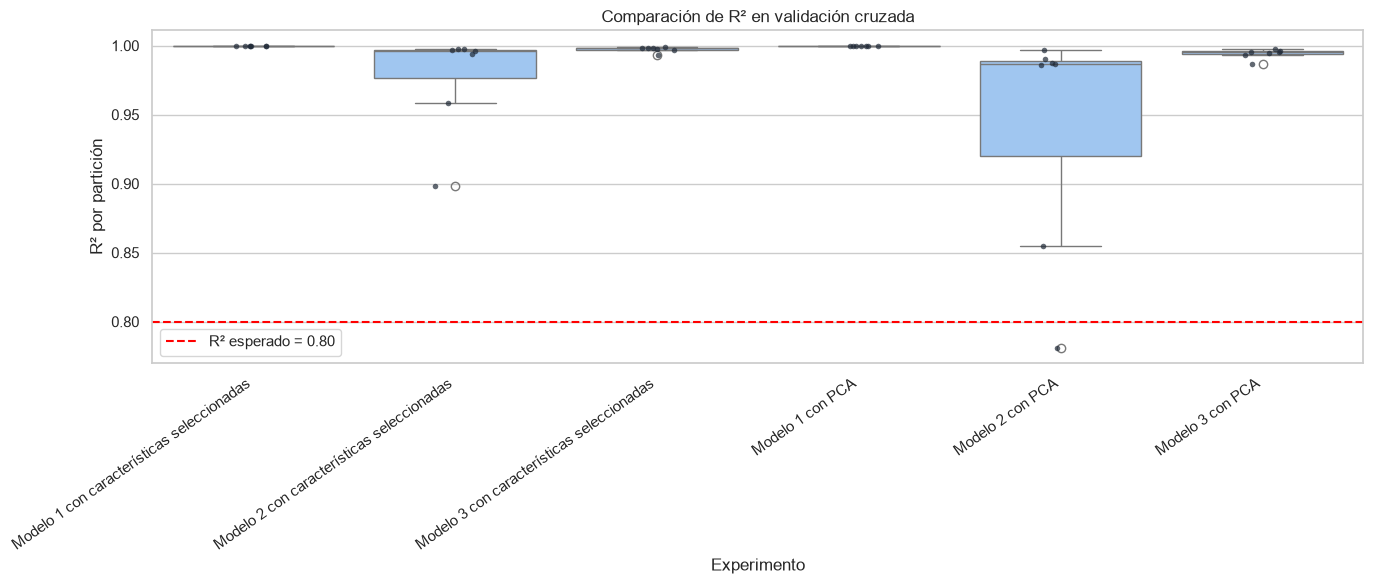

In [74]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=cv_fold_results, x='Experimento', y='R²', color='#93C5FD')
sns.stripplot(data=cv_fold_results, x='Experimento', y='R²', color='#1F2937', size=4, alpha=0.7)
plt.axhline(0.80, color='red', linestyle='--', label='R² esperado = 0.80')
plt.title('Comparación de R² en validación cruzada')
plt.xlabel('Experimento')
plt.ylabel('R² por partición')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
boxplot_analysis = (
    cv_fold_results
    .groupby(['Escenario', 'Modelo', 'Experimento'])
    .agg(
        Mediana_R2=('R²', 'median'),
        Q1_R2=('R²', lambda x: x.quantile(0.25)),
        Q3_R2=('R²', lambda x: x.quantile(0.75)),
        Min_R2=('R²', 'min'),
        Max_R2=('R²', 'max'),
        Desv_est_R2=('R²', 'std')
    )
    .reset_index()
)
boxplot_analysis['Rango intercuartílico'] = boxplot_analysis['Q3_R2'] - boxplot_analysis['Q1_R2']
boxplot_analysis['Rango total'] = boxplot_analysis['Max_R2'] - boxplot_analysis['Min_R2']
boxplot_analysis['Estabilidad'] = np.where(
    boxplot_analysis['Desv_est_R2'] <= 0.10,
    'Más estable',
    'Menos estable'
)

boxplot_analysis.sort_values('Mediana_R2', ascending=False)


,Escenario,Modelo,Experimento,Mediana_R2,Q1_R2,Q3_R2,Min_R2,Max_R2,Desv_est_R2,Rango intercuartílico,Rango total,Estabilidad
2,Características seleccionadas,Regresión Lineal,Modelo 1 con características seleccionadas,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,Más estable
5,PCA,Regresión Lineal,Modelo 1 con PCA,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,Más estable
1,Características seleccionadas,Red Neuronal MLP,Modelo 3 con características seleccionadas,0.9980,0.9970,0.9982,0.9935,0.9990,0.0018,0.0012,0.0055,Más estable
0,Características seleccionadas,Random Forest,Modelo 2 con características seleccionadas,0.9962,0.9764,0.9971,0.8983,0.9976,0.0375,0.0208,0.0993,Más estable
4,PCA,Red Neuronal MLP,Modelo 3 con PCA,0.9952,0.9940,0.9959,0.9868,0.9978,0.0036,0.0019,0.0110,Más estable
3,PCA,Random Forest,Modelo 2 con PCA,0.9868,0.9203,0.9889,0.7808,0.9970,0.0865,0.0686,0.2162,Más estable


**Interpretación del boxplot:** se comparan mediana, dispersión, rango intercuartílico y posibles particiones atípicas. Un modelo estable debe mantener R² similares entre particiones, sin depender de una sola partición con resultado alto.


### Desempeño esperado

Se espera un R² medio igual o superior a 0.80, desviación estándar reducida y varianza de R² preferentemente no superior a 0.01.


In [76]:
best_by_metrics = cv_summary.sort_values(
    ['R² medio', 'MAE medio', 'Desv. est. R²', 'Tiempo entrenamiento medio (s)'],
    ascending=[False, True, True, True]
).iloc[0]

performance_check = pd.DataFrame({
    'Criterio': [
        'R² medio >= 0.80',
        'Varianza R² <= 0.01',
        'Desv. est. R² reducida',
        'MAE consistente',
        'Enfoque declarado'
    ],
    'Resultado': [
        best_by_metrics['R² medio'] >= 0.80,
        best_by_metrics['Varianza R²'] <= 0.01,
        best_by_metrics['Desv. est. R²'] <= 0.10,
        best_by_metrics['Desv. est. MAE'] <= best_by_metrics['MAE medio'],
        True
    ],
    'Valor observado': [
        best_by_metrics['R² medio'],
        best_by_metrics['Varianza R²'],
        best_by_metrics['Desv. est. R²'],
        best_by_metrics['Desv. est. MAE'],
        'Se usa Game fuera de X y ventas regionales como variables observadas para estimar Global_Sales.'
    ]
})

performance_check


,Criterio,Resultado,Valor observado
0,R² medio >= 0.80,True,1.0000
1,Varianza R² <= 0.01,True,0.0000
2,Desv. est. R² reducida,True,0.0000
3,MAE consistente,True,0.0003
4,Enfoque declarado,True,Se usa Game fuera de X y ventas regionales com...


In [77]:
if best_by_metrics['R² medio'] < 0.80:
    improvement_attempts = pd.DataFrame({
        'Revision requerida': [
            'Preparacion de datos',
            'Caracteristicas utilizadas',
            'Hiperparametros',
            'Efecto de PCA',
            'Limitacion del dataset'
        ],
        'Accion documentada': [
            'Se imputaron nulos, se codificaron categoricas y se escalaron variables numericas dentro del pipeline.',
            'Se incluyeron ventas regionales observadas y se aplicaron correlacion, RFE e importancia de arboles.',
            'Se ajustaron parametros de Random Forest y MLP antes de evaluar con prueba.',
            'Se comparo PCA contra caracteristicas seleccionadas usando las mismas particiones.',
            'Si el desempenio fuera bajo, indicaria que las variables disponibles no explican bien el total global.'
        ]
    })
else:
    improvement_attempts = pd.DataFrame({
        'Conclusion': ['El mejor experimento alcanza el umbral esperado de R² medio >= 0.80.']
    })

improvement_attempts


,Conclusion
0,El mejor experimento alcanza el umbral esperad...


### Selección del mejor modelo

La selección considera R² medio, MAE medio, desviación estándar, varianza, estabilidad visual del boxplot, tiempo de entrenamiento, complejidad, interpretación y viabilidad de despliegue.


In [78]:
best_selected = selected_features_results.sort_values(
    ['R² medio', 'MAE medio', 'Desv. est. R²'],
    ascending=[False, True, True]
).iloc[0]

best_pca = pca_results.sort_values(
    ['R² medio', 'MAE medio', 'Desv. est. R²'],
    ascending=[False, True, True]
).iloc[0]

best_overall = best_by_metrics

pca_effect = 'mejoró' if best_pca['R² medio'] > best_selected['R² medio'] else 'empeoró o no mejoró'

best_model_decision = pd.DataFrame({
    'Pregunta': [
        'Mejor modelo con características seleccionadas',
        'Mejor modelo con PCA',
        'Efecto de PCA',
        'Mejor combinación general',
        'Razón principal de selección'
    ],
    'Respuesta': [
        best_selected['Modelo'],
        best_pca['Modelo'],
        pca_effect,
        f"{best_overall['Escenario']} - {best_overall['Modelo']}",
        'Mayor R² medio con MAE competitivo y estabilidad entre particiones.'
    ]
})

best_model_decision


,Pregunta,Respuesta
0,Mejor modelo con características seleccionadas,Regresión Lineal
1,Mejor modelo con PCA,Regresión Lineal
2,Efecto de PCA,empeoró o no mejoró
3,Mejor combinación general,Características seleccionadas - Regresión Lineal
4,Razón principal de selección,Mayor R² medio con MAE competitivo y estabilid...


### Tabla detallada del mejor modelo

Se muestran los resultados del mejor experimento en las siete particiones y sus estadísticos principales.


In [79]:
best_experiment_folds = cv_fold_results[
    (cv_fold_results['Escenario'] == best_overall['Escenario'])
    & (cv_fold_results['Modelo'] == best_overall['Modelo'])
].copy()

best_model_fold_table = best_experiment_folds[['Partición', 'R²', 'MAE']].copy()

summary_rows = pd.DataFrame({
    'Partición': ['Media', 'Desviación estándar', 'Varianza'],
    'R²': [
        best_experiment_folds['R²'].mean(),
        best_experiment_folds['R²'].std(),
        best_experiment_folds['R²'].var()
    ],
    'MAE': [
        best_experiment_folds['MAE'].mean(),
        best_experiment_folds['MAE'].std(),
        best_experiment_folds['MAE'].var()
    ]
})

best_model_fold_table = pd.concat([best_model_fold_table, summary_rows], ignore_index=True)
best_model_fold_table


,Partición,R²,MAE
0,1,1.0000,0.0022
1,2,1.0000,0.0028
2,3,1.0000,0.0023
3,4,1.0000,0.0028
4,5,1.0000,0.0030
5,6,1.0000,0.0030
6,7,1.0000,0.0026
7,Media,1.0000,0.0027
8,Desviación estándar,0.0000,0.0003
9,Varianza,0.0000,0.0000


In [80]:
best_partition = best_experiment_folds.loc[best_experiment_folds['R²'].idxmax()]
worst_partition = best_experiment_folds.loc[best_experiment_folds['R²'].idxmin()]
r2_difference = best_partition['R²'] - worst_partition['R²']

q1 = best_experiment_folds['R²'].quantile(0.25)
q3 = best_experiment_folds['R²'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
outlier_folds = best_experiment_folds[
    (best_experiment_folds['R²'] < lower_limit) | (best_experiment_folds['R²'] > upper_limit)
]

best_model_analysis = pd.DataFrame({
    'Aspecto': [
        'Mejor partición',
        'Peor partición',
        'Diferencia entre mejor y peor R²',
        'Estabilidad',
        'Particiones atípicas',
        'Representatividad de la media',
        'Magnitud de la varianza',
        'Confiabilidad general'
    ],
    'Resultado': [
        f"Partición {int(best_partition['Partición'])} con R²={best_partition['R²']:.4f}",
        f"Partición {int(worst_partition['Partición'])} con R²={worst_partition['R²']:.4f}",
        f'{r2_difference:.4f}',
        'Alta' if best_experiment_folds['R²'].std() <= 0.10 else 'Moderada o baja',
        'No se detectan' if outlier_folds.empty else ', '.join(outlier_folds['Partición'].astype(str)),
        'Adecuada' if best_experiment_folds['R²'].std() <= 0.10 else 'Revisar por variabilidad',
        f"{best_experiment_folds['R²'].var():.4f}",
        'Confiable si mantiene buen R², bajo MAE y baja variabilidad.'
    ]
})

best_model_analysis


,Aspecto,Resultado
0,Mejor partición,Partición 7 con R²=1.0000
1,Peor partición,Partición 5 con R²=1.0000
2,Diferencia entre mejor y peor R²,0.0000
3,Estabilidad,Alta
4,Particiones atípicas,No se detectan
5,Representatividad de la media,Adecuada
6,Magnitud de la varianza,0.0000
7,Confiabilidad general,"Confiable si mantiene buen R², bajo MAE y baja..."


## 3.7 Evaluación final del mejor modelo

Después de comparar los seis experimentos, se evalúa únicamente el mejor modelo con el conjunto de prueba reservado. Se mantiene la misma configuración de preprocesamiento, representación y algoritmo usada en validación cruzada.


### División de entrenamiento y prueba

La división ya se realizó con `train_test_split`: 80% entrenamiento, 20% prueba y `random_state=42`. El conjunto de prueba no se usó para selección de variables, PCA, ajuste de hiperparámetros ni validación cruzada.


In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_scenario = best_overall['Escenario']
best_model_name = best_overall['Modelo']

best_final_pipeline = experiment_builders[best_scenario](clone(model_definitions[best_model_name]))
best_final_pipeline.fit(X_train, y_train)

y_pred = best_final_pipeline.predict(X_test)
residuals = y_test - y_pred

final_test_metrics = pd.DataFrame({
    'Métrica': ['R²', 'MAE', 'RMSE'],
    'Resultado en prueba': [
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
})

print(f'Mejor experimento seleccionado: {best_scenario} - {best_model_name}')
print(f'Tamaño entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0] / len(X):.0%})')
print(f'Tamaño prueba: {X_test.shape[0]} registros ({X_test.shape[0] / len(X):.0%})')
final_test_metrics


Mejor experimento seleccionado: Características seleccionadas - Regresión Lineal
Tamaño entrenamiento: 827 registros (80%)
Tamaño prueba: 207 registros (20%)


,Métrica,Resultado en prueba
0,R²,1.0000
1,MAE,0.0027
2,RMSE,0.0047


### Gráfica de valores reales contra valores predichos

La línea diagonal representa una predicción ideal: mientras más cerca estén los puntos de esa línea, menor es el error.


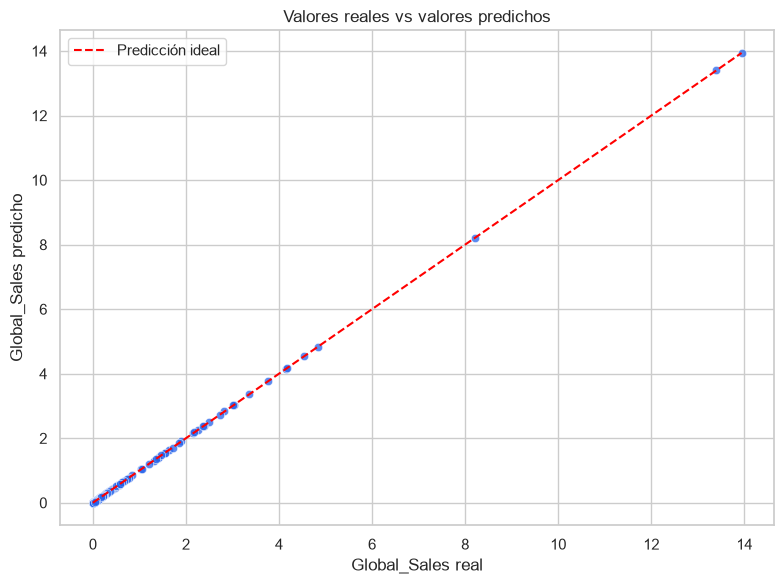

In [82]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.75, color='#2563EB')

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', label='Predicción ideal')

plt.title('Valores reales vs valores predichos')
plt.xlabel('Global_Sales real')
plt.ylabel('Global_Sales predicho')
plt.legend()
plt.tight_layout()
plt.show()


In [83]:
prediction_analysis = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred,
    'Residuo': residuals,
    'Error absoluto': np.abs(residuals)
})

prediction_analysis['Tipo de error'] = np.where(
    prediction_analysis['Residuo'] > 0,
    'Subestimación',
    np.where(prediction_analysis['Residuo'] < 0, 'Sobreestimación', 'Exacto')
)

prediction_analysis['Rango de venta real'] = pd.qcut(
    prediction_analysis['Real'],
    q=4,
    duplicates='drop'
)

error_by_sales_range = (
    prediction_analysis
    .groupby('Rango de venta real', observed=False)
    .agg(
        Registros=('Real', 'count'),
        Real_promedio=('Real', 'mean'),
        Predicho_promedio=('Predicho', 'mean'),
        MAE=('Error absoluto', 'mean'),
        Residuo_promedio=('Residuo', 'mean')
    )
    .reset_index()
)

display(prediction_analysis.sort_values('Error absoluto', ascending=False).head(10))
display(prediction_analysis['Tipo de error'].value_counts().rename_axis('Tipo de error').reset_index(name='Cantidad'))
display(error_by_sales_range)


,Real,Predicho,Residuo,Error absoluto,Tipo de error,Rango de venta real
256,0.3600,0.3786,-0.0186,0.0186,Sobreestimación,"(0.34, 13.94]"
289,0.2800,0.2664,0.0136,0.0136,Subestimación,"(0.06, 0.34]"
331,0.2100,0.2228,-0.0128,0.0128,Sobreestimación,"(0.06, 0.34]"
218,0.5000,0.5123,-0.0123,0.0123,Sobreestimación,"(0.34, 13.94]"
92,1.7200,1.7086,0.0114,0.0114,Subestimación,"(0.34, 13.94]"
346,0.1800,0.1913,-0.0113,0.0113,Sobreestimación,"(0.06, 0.34]"
39,3.7700,3.7587,0.0113,0.0113,Subestimación,"(0.34, 13.94]"
350,0.1700,0.1813,-0.0113,0.0113,Sobreestimación,"(0.06, 0.34]"
209,0.5600,0.5490,0.0110,0.0110,Subestimación,"(0.34, 13.94]"
679,0.0100,0.0210,-0.0110,0.0110,Sobreestimación,"(-0.001, 0.06]"


,Tipo de error,Cantidad
0,Sobreestimación,128
1,Subestimación,79


,Rango de venta real,Registros,Real_promedio,Predicho_promedio,MAE,Residuo_promedio
0,"(-0.001, 0.06]",106,0.0158,0.0158,0.0012,0.0000
1,"(0.06, 0.34]",49,0.1818,0.1824,0.0036,-0.0005
2,"(0.34, 13.94]",52,2.2415,2.2424,0.0050,-0.0009


**Análisis:** si los puntos se alejan de la línea ideal, el modelo comete más error. Los puntos por debajo de la línea representan subestimaciones y los puntos por encima sobreestimaciones. El resumen por rangos permite identificar si los errores crecen en juegos con ventas bajas, medias o altas.


### Gráfica de residuos

Los residuos se calculan como `valor real - valor predicho`. La línea horizontal en cero indica ausencia de error.


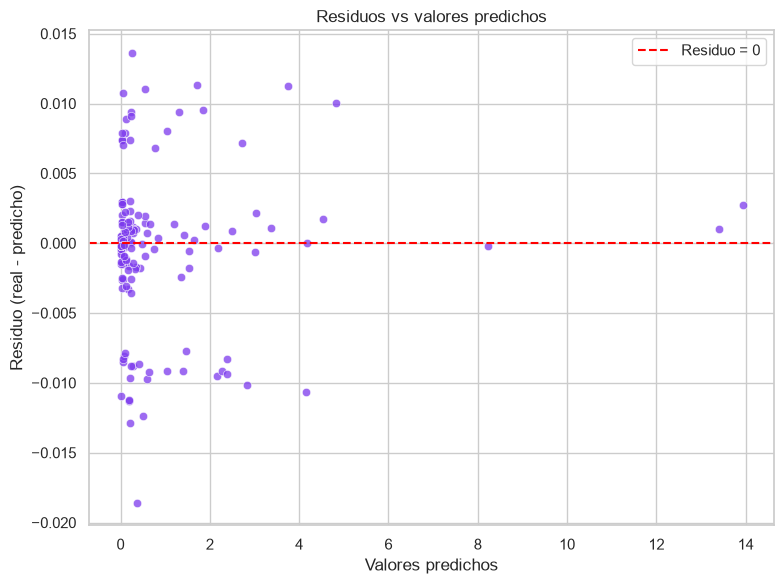

In [84]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.75, color='#7C3AED')
plt.axhline(0, color='red', linestyle='--', label='Residuo = 0')
plt.title('Residuos vs valores predichos')
plt.xlabel('Valores predichos')
plt.ylabel('Residuo (real - predicho)')
plt.legend()
plt.tight_layout()
plt.show()


In [85]:
residual_summary = pd.DataFrame({
    'Estadístico': [
        'Media de residuos',
        'Mediana de residuos',
        'Desv. est. de residuos',
        'Residuo mínimo',
        'Residuo máximo',
        'Error absoluto medio',
        'Cantidad de errores extremos'
    ],
    'Valor': [
        residuals.mean(),
        residuals.median(),
        residuals.std(),
        residuals.min(),
        residuals.max(),
        np.abs(residuals).mean(),
        int((np.abs(residuals) > (np.abs(residuals).mean() + 2 * np.abs(residuals).std())).sum())
    ]
})

residual_by_pred_range = (
    prediction_analysis
    .assign(Rango_predicho=pd.qcut(prediction_analysis['Predicho'], q=4, duplicates='drop'))
    .groupby('Rango_predicho', observed=False)
    .agg(
        Registros=('Predicho', 'count'),
        Residuo_promedio=('Residuo', 'mean'),
        Dispersion_residuos=('Residuo', 'std'),
        MAE=('Error absoluto', 'mean')
    )
    .reset_index()
)

display(residual_summary)
display(residual_by_pred_range)


,Estadístico,Valor
0,Media de residuos,-0.0003
1,Mediana de residuos,-0.0002
2,Desv. est. de residuos,0.0047
3,Residuo mínimo,-0.0186
4,Residuo máximo,0.0136
5,Error absoluto medio,0.0027
6,Cantidad de errores extremos,12.0000


,Rango_predicho,Registros,Residuo_promedio,Dispersion_residuos,MAE
0,"(-0.001505, 0.000398]",57,-0.0002,0.0002,0.0003
1,"(0.000398, 0.0602]",47,0.0003,0.0039,0.0024
2,"(0.0602, 0.34]",51,-0.0006,0.0053,0.0035
3,"(0.34, 13.937]",52,-0.0009,0.0068,0.0050


**Análisis de residuos:** una distribución adecuada debería estar centrada cerca de cero y sin patrones claros. Si los residuos aumentan o disminuyen conforme crece la predicción, hay indicios de sesgo o heterocedasticidad. Errores extremos pueden indicar juegos difíciles de predecir por información faltante en el dataset, como reseñas, popularidad, presupuesto o campañas de marketing.


### Conclusión de evaluación final

La evaluación final permite observar el comportamiento del mejor modelo en datos no usados para entrenar ni seleccionar el experimento. Las gráficas y tablas muestran si el modelo generaliza, si presenta sesgo sistemático y en qué rangos de ventas tiene mayor dificultad.


## 3.8 Despliegue del modelo

El mejor modelo se despliega con Flask y Render. La aplicación carga un pipeline completo guardado con `joblib`, muestra un formulario con variables originales y devuelve la predicción de `Global_Sales` en millones de copias.


### Entrenamiento y almacenamiento

Después de finalizar la evaluación, el pipeline del mejor experimento se vuelve a entrenar con todos los registros disponibles. El pipeline incluye imputación, codificación, escalado, PCA o selección de características y el algoritmo de regresión.


In [ ]:
import json
import shutil
import joblib

deployment_dir = Path('render_app')
deployment_dir.mkdir(exist_ok=True)

final_deployment_pipeline = experiment_builders[best_scenario](clone(model_definitions[best_model_name]))
final_deployment_pipeline.fit(X, y)

model_path = deployment_dir / 'model_pipeline.joblib'
metadata_path = deployment_dir / 'model_metadata.json'

joblib.dump(final_deployment_pipeline, model_path)

deployment_metadata = {
    'dataset': 'PS4_GamesSales.csv',
    'target': target,
    'target_unit': 'millones de copias vendidas',
    'input_features': feature_cols,
    'removed_columns': removed_columns,
    'regional_sales_features': regional_sales_cols,
    'best_scenario': str(best_scenario),
    'best_model': str(best_model_name),
    'selected_features': selected_features,
    'pca_components': int(n_components_95),
    'genres': sorted(dataset['Genre'].dropna().astype(str).unique().tolist()),
    'publishers': sorted(dataset['Publisher'].fillna('Unknown').astype(str).unique().tolist()),
    'year_min': None if pd.isna(dataset['Year'].min()) else int(dataset['Year'].min()),
    'year_max': None if pd.isna(dataset['Year'].max()) else int(dataset['Year'].max()),
    'sales_min': float(dataset[regional_sales_cols].min().min()),
    'sales_max': float(dataset[regional_sales_cols].max().max()),
}

if 'Unknown' not in deployment_metadata['publishers']:
    deployment_metadata['publishers'].insert(0, 'Unknown')

with open(metadata_path, 'w', encoding='utf-8') as file:
    json.dump(deployment_metadata, file, ensure_ascii=False, indent=2)

dataset_raw.to_csv(deployment_dir / 'PS4_GamesSales.csv', index=False, encoding='latin1')

url_file = Path('URL_Render.txt')
render_public_url = 'https://ps4-global-sales-predictor.onrender.com/'
url_file.write_text(render_public_url, encoding='utf-8')

pd.DataFrame({
    'Archivo generado': [str(model_path), str(metadata_path), str(deployment_dir / 'PS4_GamesSales.csv'), str(url_file)],
    'Proposito': [
        'Pipeline final entrenado.',
        'Datos auxiliares para formulario y descripcion del modelo.',
        'Dataset usado para reproducir entrenamiento.',
        'Archivo donde se coloca la URL publica de Render.'
    ]
})


### Servicio web con Flask

La carpeta `render_app` contiene la aplicacion. El usuario ingresa `Year`, `Genre`, `Publisher`, `North America`, `Europe`, `Japan` y `Rest of World`, que son variables originales del dataset. El usuario no ingresa valores escalados, variables one-hot ni componentes principales; el pipeline realiza esas transformaciones internamente.


In [87]:
deployment_files = pd.DataFrame({
    'Archivo': [
        'render_app/app.py',
        'render_app/model_utils.py',
        'render_app/train_model.py',
        'render_app/model_pipeline.joblib',
        'render_app/model_metadata.json',
        'render_app/requirements.txt',
        'render_app/render.yaml',
        'render_app/.python-version',
        'render_app/templates/index.html',
        'render_app/static/styles.css'
    ],
    'Uso': [
        'Aplicación Flask: carga el pipeline, valida formulario y predice.',
        'Clase auxiliar usada por el pipeline guardado.',
        'Script reproducible para entrenar y guardar el modelo.',
        'Pipeline final entrenado.',
        'Categorías, escenario y modelo seleccionado.',
        'Dependencias necesarias en Render.',
        'Configuración opcional del servicio en Render.',
        'Versión de Python usada para el despliegue.',
        'Formulario HTML.',
        'Estilos de la interfaz.'
    ]
})

deployment_files


,Archivo,Uso
0,render_app/app.py,"Aplicación Flask: carga el pipeline, valida fo..."
1,render_app/model_utils.py,Clase auxiliar usada por el pipeline guardado.
2,render_app/train_model.py,Script reproducible para entrenar y guardar el...
3,render_app/model_pipeline.joblib,Pipeline final entrenado.
4,render_app/model_metadata.json,"Categorías, escenario y modelo seleccionado."
5,render_app/requirements.txt,Dependencias necesarias en Render.
6,render_app/render.yaml,Configuración opcional del servicio en Render.
7,render_app/.python-version,Versión de Python usada para el despliegue.
8,render_app/templates/index.html,Formulario HTML.
9,render_app/static/styles.css,Estilos de la interfaz.


### Configuración en Render

En Render se debe crear un Web Service conectado al repositorio que contenga la carpeta `render_app`.

- **Build Command:** `pip install -r requirements.txt`
- **Start Command:** `gunicorn app:app`
- **Root Directory:** `render_app`, si el repositorio contiene también otros archivos.
- **URL pública:** https://ps4-global-sales-predictor.onrender.com/


### Pruebas realizadas

La aplicación se probó localmente abriendo la página, enviando el formulario con datos reales del dataset y verificando que se generara una predicción sin errores. En Render deberán repetirse las mismas pruebas y capturar evidencias de la página, formulario y resultado.


## 3.9 Conclusiones y reflexion critica

En este proyecto aprendi que el dataset de videojuegos PS4 tiene una relacion muy fuerte entre las ventas regionales y `Global_Sales`. La mayoria de juegos presenta ventas bajas o incluso cero, mientras que pocos titulos concentran ventas muy altas. Por eso, el problema no solo depende del algoritmo, sino tambien de entender correctamente que informacion representa cada columna.

Los principales problemas de calidad fueron valores faltantes en `Year` y `Publisher`, valores `N/A`, muchos ceros en ventas, atipicos importantes y la columna `Game` como identificador. Los valores faltantes se trataron dentro del pipeline: mediana para variables numericas y `Unknown` para categoricas. Esto evita eliminar registros sin necesidad y reduce fuga de informacion, porque el ajuste se hace solo con los datos de entrenamiento.

La codificacion one-hot fue necesaria para `Genre` y `Publisher`, ya que son variables nominales y no tienen un orden natural. Esta codificacion aumento el numero de columnas, pero permitio que los modelos usaran categorias sin imponer jerarquias falsas. Tambien fue necesario escalar las variables numericas con `StandardScaler`, principalmente por PCA, regresion lineal y la red neuronal, que son sensibles a la escala de las variables.

Las caracteristicas seleccionadas finales fueron `Rest of World`, `Europe`, `North America`, `Japan`, `Year` y `Genre_Sports`. Correlacion, RFE y arboles coincidieron en que las ventas regionales eran las variables mas importantes. Difirieron en variables secundarias como `Year` o algunas categorias codificadas, porque cada metodo evalua la relacion con el objetivo de forma distinta. La seleccion de caracteristicas fue ventajosa porque mantuvo un modelo simple, interpretable y con muy buen desempenio.

PCA permitio reducir dimensionalidad despues de imputar, codificar y escalar. Su ventaja fue resumir muchas columnas en componentes principales y mantener gran parte de la varianza. Su desventaja fue la perdida de interpretacion: los componentes no son tan claros como las variables originales. En los resultados, PCA no mejoro al mejor modelo; tuvo un desempenio muy alto, pero fue ligeramente inferior al escenario con caracteristicas seleccionadas.

El mejor desempenio lo obtuvo `Regresion Lineal` con caracteristicas seleccionadas. Tambien fue el modelo mas estable, con R2 medio de 0.99999, MAE medio de 0.00267 y desviacion estandar de R2 practicamente nula. Si se alcanzo el umbral de R2 mayor a 0.80. La varianza tan baja indica que el resultado fue consistente entre particiones y no dependio de una sola corrida favorable.

La grafica de valores reales contra predichos mostro puntos muy cercanos a la linea ideal. Los residuos quedaron concentrados alrededor de cero, sin un patron fuerte, lo que indica buen ajuste. Aun asi, el modelo puede tener errores por redondeo o por casos extremos, especialmente porque `Global_Sales` esta directamente relacionado con la suma regional.

La principal limitacion es que el modelo estima ventas globales usando ventas regionales observadas; por lo tanto, no debe interpretarse como una prediccion antes del lanzamiento. Tambien el dataset se limita a PS4 y no incluye factores como precio, marketing, resenas, fecha exacta de salida, competencia o ventas digitales completas. Para mejorar el estudio, se podrian integrar mas plataformas, datos recientes, variables comerciales y una validacion externa con datos no vistos.

Usar el modelo en un entorno real tendria riesgos si se interpreta fuera de su alcance. Si las ventas regionales ingresadas son incorrectas, la prediccion global tambien lo sera. Se eligio publicar en Render el modelo de regresion lineal con caracteristicas seleccionadas porque fue el mas preciso, estable, rapido, facil de explicar y sencillo de desplegar como pipeline completo.
